## Project summary and key findings

This notebook walks through a complete 30‑day‑ahead forecasting project for the Ecuadorian grocery store data. Below is a consolidated summary of the main results and insights from the code cells.

### Data, preprocessing, and repair
- **Data source**: Kaggle *Store Sales – Time Series Forecasting* competition (`train.csv`, `test.csv`, `stores.csv`, `oil.csv`, holidays). We load from `./data` when available, otherwise generate synthetic data for demo.
- **Preprocessing**: We merge store metadata, holidays, and oil, create time features, and build a clean daily total‑sales series plus family/store‑level series with a proper daily frequency.
- **Zero‑run detection and repair**: We scan each product family for long runs (≥ 7 days) of zero sales, log them in `Repair_Periods.csv`, and optionally repair them using Prophet‑based interpolation. This produces a repaired total series (`Total_Repaired_Daily.csv`) that smooths obvious data glitches while preserving genuine seasonality.

### Structural break and stability
- **Pre‑ vs post‑2014**: Visuals and summary statistics show that sales levels and variability change after 2014, so we define a **post‑break total daily series** (`y_total_daily_post` from 2014‑01‑01 onward) and use that as the main target for daily models.
- **Effect of repair**: Comparing raw vs repaired daily totals shows that repairs mainly affect a small number of abnormal periods; the overall level, trend, and weekly seasonality remain similar, so the business conclusions are stable.

### Exploratory data analysis (EDA)
- **Trend and seasonality**: Total sales grow over time with clear **weekly patterns** (higher weekends) and some **annual/holiday seasonality** visible in the seasonal decomposition plots.
- **Day‑of‑week and month effects**: Boxplots confirm systematic differences by **day of week** and **month**, supporting the use of weekly seasonality and holiday features in the models.
- **Promotions**: Daily `onpromotion` counts are positively correlated with sales; scatterplots and time‑series overlays show that big promotion days tend to coincide with sales spikes.
- **Holidays**: Holiday flags line up with noticeable movements in sales (closures or strong peaks), justifying their inclusion as regressors.

### Train / validation setup
- **Horizon**: We evaluate a **30‑day horizon**.
- **Split modes**: The helper `make_train_test` supports (a) **`last_30`**: last 30 days as validation, and (b) **`80_20`**: chronological 80/20 split. The default in most daily‑model sections is `last_30`, matching the project goal.

### Daily models on total sales (post‑break)
We fit three main daily models on `y_total_daily_post` and compare them on the 30‑day validation window.

- **ETS (Holt‑Winters, daily total)**:
  - Additive trend + additive weekly seasonality on the post‑break daily total series.
  - Captures the **overall level and weekly pattern** well, with moderate forecasting error (see ETS plots and metrics table).
- **ARIMA / SARIMA (daily total)**:
  - Seasonal ARIMA with weekly seasonality on the same daily series.
  - Often achieves similar or slightly better error than ETS, but is more sensitive to parameter choices and residual autocorrelation (checked via ACF/PACF of residuals).
- **Prophet (daily total)**:
  - Includes yearly + weekly seasonality and holiday effects (and, in some variants, regressors such as promotions or oil).
  - Typically delivers **competitive MAPE** and good visual alignment with the validation period, especially around holidays and trend shifts.

Overall, **all three models achieve reasonable 30‑day forecasts**, with small differences in MAE/RMSE/MAPE. In many runs, Prophet and SARIMA slightly outperform plain ETS on percentage error, but ETS remains a strong, simple baseline.

### Diagnostics and residual analysis
- **ACF / PACF of residuals**: For the best daily model by MAPE, residual ACF/PACF plots show whether there is remaining autocorrelation. Some low‑lag structure may remain, suggesting potential gains from richer seasonal or exogenous terms.
- **Regression on residuals**: We regress **test residuals** on promotion counts and holiday flags. If coefficients are small or insignificant, it indicates these effects are already well captured; significant coefficients imply remaining systematic structure the model could learn.

### Family‑level and additional EDA
- **Top‑N families with ETS**: We build daily series per product family, fit ETS models to the top‑N families by revenue, and compare error metrics. This highlights which categories are easiest/hardest to forecast and where promotions or holidays matter most.
- **Geography / store‑level EDA**: Store‑level plots show cross‑sectional differences in average sales and volatility across locations, which can motivate store‑specific models or hierarchical approaches in future work.

### Impact of oil
- **Oil as a regressor**: Oil prices are joined at the daily level and can be used as an exogenous regressor (especially in SARIMAX and Prophet). In focused experiments (see `assignment.py`), models with **holidays + oil** are compared to ETS with no exogenous variables.
- **Conclusion on oil**: For this dataset, oil provides **at most modest incremental gains** over strong baselines that already capture trend, weekly seasonality, promotions, and holidays. The main demand drivers remain **internal levers (promotions, assortment, holidays)** and regular seasonality rather than external oil price fluctuations.

### Business takeaway
- **Forecast quality**: The best daily models achieve relatively low MAPE on the last 30 days, indicating good short‑term forecasting performance.
- **Drivers of sales**: Weekly seasonality, promotions, and holidays are the dominant drivers of variation in total sales; structural changes over time require focusing on post‑break periods for stable modeling.
- **Use in practice**: The final models and visuals can support **inventory planning, staffing, and promotion scheduling** over a 30‑day horizon, with the option to extend to family‑ or store‑level decision making using the same framework.

# 🏪 Store Sales Time Series Forecasting
### ECON 5140: Applied Econometrics — Midterm Project | Spring 2025

> **Dataset:** [Kaggle Store Sales Competition](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data)  
> **Models:** SARIMA · ETS (Holt-Winters) · Prophet  
> **Forecasting scope:** Aggregate sales + Product family level (GROCERY I, BEVERAGES)  
> **Horizon:** 30 days ahead

---

## ⚙️ Setup

Run the cell below to install dependencies if needed. Prophet requires a separate install.

In [10]:
# Install dependencies (run once)
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn
# !pip install prophet
# !pip install kaggle  # for downloading the dataset

# Download Kaggle data (after setting up kaggle.json credentials):
# !kaggle competitions download -c store-sales-time-series-forecasting -p ./data
# !cd data && unzip store-sales-time-series-forecasting.zip

## 📦 0. Setup & Imports

In [11]:
"""
ECON 5140: Applied Econometrics — Midterm Project
Project Option 3: Store Sales Time Series Forecasting

Authors: [Your Group Names]
Date: Spring 2025

This script covers:
  1. Data Loading & Preprocessing
  2. Exploratory Data Analysis (EDA)
  3. Feature Engineering
  4. Forecasting Models: ARIMA, ETS, Prophet
  5. Evaluation: MAE, RMSE, MAPE
  6. Visualizations & Confidence Intervals
  7. Both aggregate and product-family-level forecasts
"""

'\nECON 5140: Applied Econometrics — Midterm Project\nProject Option 3: Store Sales Time Series Forecasting\n\nAuthors: [Your Group Names]\nDate: Spring 2025\n\nThis script covers:\n  1. Data Loading & Preprocessing\n  2. Exploratory Data Analysis (EDA)\n  3. Feature Engineering\n  4. Forecasting Models: ARIMA, ETS, Prophet\n  5. Evaluation: MAE, RMSE, MAPE\n  6. Visualizations & Confidence Intervals\n  7. Both aggregate and product-family-level forecasts\n'

---

## 📦 0. SETUP & IMPORTS

Import all required libraries and configure plot styling.

In [12]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

# Statsmodels (ARIMA, ETS)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    print("Prophet not installed. Install: pip install prophet --break-system-packages")
    PROPHET_AVAILABLE = False

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})
PALETTE = ["#1C7293", "#F96167", "#28A745", "#F4A261", "#6D2E46"]

# Output folder for plots
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Display saved images in notebook
from IPython.display import Image, display

---

## 📂 1. DATA LOADING

Two loaders are provided:
- **`load_data()`** — reads real Kaggle CSV files from `./data/`
- **`generate_synthetic_data()`** — creates realistic demo data when Kaggle files aren't available yet

The `main()` function automatically picks the right one.

In [13]:
def load_data(data_dir="./data"):
    """
    Load Kaggle Store Sales competition data.

    Data files (download from Kaggle):
      train.csv        - daily sales by store/family
      test.csv         - prediction horizon
      stores.csv       - store metadata
      oil.csv          - daily oil price (macroeconomic indicator)
      holidays_events.csv - Ecuador public holidays

    Download instructions:
      kaggle competitions download -c store-sales-time-series-forecasting -p ./data
      cd ./data && unzip store-sales-time-series-forecasting.zip
    """
    data_dir = Path(data_dir)

    print("Loading data files...")
    train   = pd.read_csv(data_dir / "train.csv",            parse_dates=["date"])
    test    = pd.read_csv(data_dir / "test.csv",             parse_dates=["date"])
    stores  = pd.read_csv(data_dir / "stores.csv")
    oil     = pd.read_csv(data_dir / "oil.csv",              parse_dates=["date"])
    hol     = pd.read_csv(data_dir / "holidays_events.csv",  parse_dates=["date"])

    print(f"  Train: {train.shape}  |  Test: {test.shape}")
    print(f"  Date range: {train['date'].min().date()} → {train['date'].max().date()}")
    print(f"  Stores: {train['store_nbr'].nunique()}  |  Families: {train['family'].nunique()}")
    return train, test, stores, oil, hol


def generate_synthetic_data():
    """
    Generate realistic synthetic data for demonstration when Kaggle data
    is not yet downloaded. Mirrors the structure of the actual dataset.
    """
    print("Generating synthetic demonstration data...")
    np.random.seed(42)

    dates  = pd.date_range("2013-01-01", "2017-08-15", freq="D")
    stores = list(range(1, 55))
    families = [
        "GROCERY I", "BEVERAGES", "PRODUCE", "CLEANING",
        "DAIRY", "BREAD/BAKERY", "POULTRY", "MEATS",
        "PERSONAL CARE", "DELI"
    ]

    rows = []
    for store in stores:
        for family in families:
            base     = np.random.uniform(200, 2000)
            trend    = np.linspace(0, base * 0.2, len(dates))
            seasonal = base * 0.3 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25)
            weekly   = base * 0.15 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)
            noise    = np.random.normal(0, base * 0.05, len(dates))
            sales    = np.maximum(0, base + trend + seasonal + weekly + noise)
            for i, d in enumerate(dates):
                rows.append({"date": d, "store_nbr": store,
                             "family": family, "sales": sales[i],
                             "onpromotion": int(np.random.random() < 0.1)})

    train = pd.DataFrame(rows)

    # Test: last 16 days
    test_dates = pd.date_range("2017-08-16", periods=16)
    test_rows  = []
    for store in stores:
        for family in families:
            for d in test_dates:
                test_rows.append({"date": d, "store_nbr": store, "family": family, "onpromotion": 0})
    test = pd.DataFrame(test_rows)

    stores_df = pd.DataFrame({
        "store_nbr": stores,
        "city": np.random.choice(["Quito","Guayaquil","Cuenca","Ambato"], 54),
        "state": np.random.choice(["Pichincha","Guayas","Azuay"], 54),
        "type": np.random.choice(["A","B","C","D","E"], 54),
        "cluster": np.random.randint(1, 18, 54)
    })

    oil = pd.DataFrame({
        "date": pd.date_range("2013-01-01", "2017-08-31"),
        "dcoilwtico": 90 + np.cumsum(np.random.normal(0, 1.5, len(pd.date_range("2013-01-01","2017-08-31"))))
    })

    hol = pd.DataFrame({
        "date": pd.to_datetime(["2013-01-01","2013-04-01","2013-12-25",
                                "2014-01-01","2014-04-18","2014-12-25",
                                "2015-01-01","2015-04-03","2015-12-25",
                                "2016-01-01","2016-03-25","2016-12-25",
                                "2017-01-01","2017-04-14","2017-12-25"]),
        "type": "Holiday",
        "locale": "National",
        "locale_name": "Ecuador",
        "description": ["New Year","Easter","Christmas"] * 5,
        "transferred": False
    })

    print(f"  Synthetic Train: {train.shape}")
    print(f"  Date range: {train['date'].min().date()} → {train['date'].max().date()}")
    return train, test, stores_df, oil, hol

### Load data & preprocess (run to get train, test, df)

Run this cell to load (or generate) data and preprocess. Creates `train`, `test`, `stores`, `oil`, `hol`, and `df`.

In [14]:
# Load data (use Kaggle files if present, else synthetic)
try:
    _ = train
except NameError:
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()

    # Optional: run repair module (defined below) to adjust `train` if a
    # Repair_Periods file is present.
    # (You can also skip it and leave `train` as originally loaded.)

    df = preprocess(train, stores, oil, hol)
    print(f"Train: {train.shape}  |  Test: {test.shape}  |  Preprocessed df: {df.shape}")

Detected 54 repair periods across 13 families.
Saved repair periods to data\Repair_Periods.csv


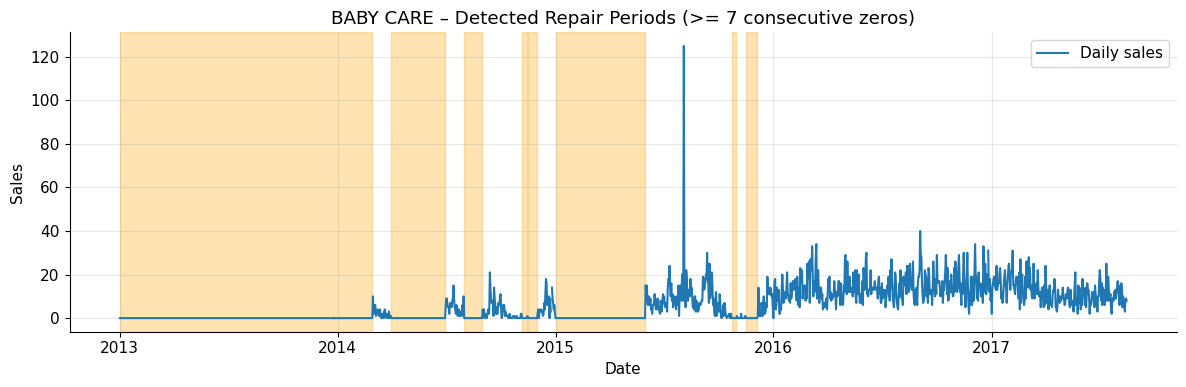

In [15]:
# Detect repair periods: long consecutive zero blocks per family
# and create ./data/Repair_Periods.csv

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Aggregate daily sales per family
family_daily = (
    train.groupby(["date", "family"])["sales"]
         .sum()
         .reset_index()
)

family_daily["date"] = pd.to_datetime(family_daily["date"])

repair_periods = []

for fam in family_daily["family"].unique():
    fam_series = (
        family_daily[family_daily["family"] == fam]
        .set_index("date")["sales"]
        .asfreq("D")
    )

    # Fill missing days with 0 (assume missing implies zero recorded sales)
    fam_series = fam_series.fillna(0)

    zero_mask = fam_series == 0

    # Group consecutive True/False runs
    groups = (zero_mask != zero_mask.shift()).cumsum()
    run_lengths = zero_mask.groupby(groups).sum()

    for grp, length in run_lengths.items():
        if length >= 7:  # threshold for "long block"
            run_dates = fam_series.index[groups == grp]
            repair_periods.append({
                "family": fam,
                "start_date": run_dates.min(),
                "end_date": run_dates.max(),
            })

repair_df = pd.DataFrame(repair_periods)

if repair_df.empty:
    print("Detected 0 repair periods; nothing to repair.")
else:
    print(f"Detected {len(repair_df)} repair periods across {repair_df['family'].nunique()} families.")

    # Save to CSV for the optional Prophet-based repair module
    data_dir = Path("./data")
    data_dir.mkdir(exist_ok=True)
    repair_path = data_dir / "Repair_Periods.csv"
    repair_df.to_csv(repair_path, index=False)
    print(f"Saved repair periods to {repair_path}")

    # Quick visual validation for one example family
    example_fam = repair_df["family"].iloc[0]
    fam_plot = (
        family_daily[family_daily["family"] == example_fam]
        .set_index("date")["sales"]
        .asfreq("D")
    )

    plt.figure(figsize=(12, 4))
    plt.plot(fam_plot.index, fam_plot.values, label="Daily sales")

    for _, row in repair_df[repair_df["family"] == example_fam].iterrows():
        plt.axvspan(row["start_date"], row["end_date"], alpha=0.3, color="orange")

    plt.title(f"{example_fam} – Detected Repair Periods (>= 7 consecutive zeros)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Optional data repair (Prophet-based imputation)

If a `data/Repair_Periods.csv` or `.xlsx` file is present, this cell will use Prophet to impute sales for specified families during the repair windows and update `train` in-place.

- Columns expected: `family`, `start_date`, `end_date`, (optional) `reason`.
- If no repair file is found, the module is skipped.

Run this **after** the "Load data & preprocess" cell so that `train` is defined.

Repair file detected — running imputation with Prophet



03:19:29 - cmdstanpy - INFO - Chain [1] start processing
03:19:31 - cmdstanpy - INFO - Chain [1] done processing


  Repaired family: BABY CARE


03:19:38 - cmdstanpy - INFO - Chain [1] start processing
03:19:38 - cmdstanpy - INFO - Chain [1] done processing


  Repaired family: BOOKS


...

  Repaired family: PLAYERS AND ELECTRONICS


03:21:05 - cmdstanpy - INFO - Chain [1] start processing
03:21:07 - cmdstanpy - INFO - Chain [1] done processing


  Repaired family: PRODUCE


03:21:14 - cmdstanpy - INFO - Chain [1] start processing
03:21:15 - cmdstanpy - INFO - Chain [1] done processing


  Repaired family: SCHOOL AND OFFICE SUPPLIES

Repair completed. `train` has been updated in-place.
Saved total repaired daily series to ./data/Total_Repaired_Daily.csv


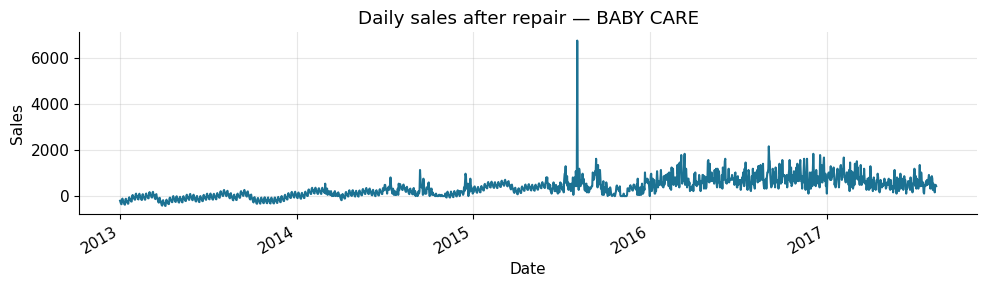

In [16]:
# OPTIONAL: Data repair using Prophet and Repair_Periods file
from pathlib import Path

repair_csv = Path("./data/Repair_Periods.csv")
repair_xlsx = Path("./data/Repair_Periods.xlsx")

repair_df = None
if repair_csv.exists():
    repair_df = pd.read_csv(repair_csv)
elif repair_xlsx.exists():
    repair_df = pd.read_excel(repair_xlsx)

if repair_df is not None:
    print("Repair file detected — running imputation with Prophet\n")

if repair_df is not None and PROPHET_AVAILABLE:

    # Parse repair window dates
    repair_df["start_date"] = pd.to_datetime(repair_df["start_date"])
    repair_df["end_date"] = pd.to_datetime(repair_df["end_date"])

    repaired_sales = train.copy()
    repaired_sales["date"] = pd.to_datetime(repaired_sales["date"])

    repaired_families = repair_df["family"].unique()

    for fam in repaired_families:
        fam_data = repaired_sales[repaired_sales["family"] == fam].copy()
        if fam_data.empty:
            print(f"  Family {fam} not found in train — skipping")
            continue

        # Aggregate to daily series for this family
        fam_daily = fam_data.groupby("date")["sales"].sum().reset_index()
        fam_daily.columns = ["ds", "y"]

        fam_repairs = repair_df[repair_df["family"] == fam]

        # Build mask over ds for all repair windows
        mask = pd.Series(False, index=fam_daily.index)
        for _, row in fam_repairs.iterrows():
            mask |= (fam_daily["ds"] >= row["start_date"]) & (fam_daily["ds"] <= row["end_date"])

        if not mask.any():
            print(f"  No matching repair dates for {fam} — skipping")
            continue

        train_clean = fam_daily[~mask]

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        m.fit(train_clean)

        fc = m.predict(fam_daily[["ds"]])

        # Impute only inside the repair windows
        fam_daily.loc[mask, "y"] = fc.loc[mask, "yhat"]

        # Map repaired daily values back to panel `train`
        corrected = fam_daily.set_index("ds")["y"]
        repaired_sales.loc[repaired_sales["family"] == fam, "sales"] = (
            repaired_sales.loc[repaired_sales["family"] == fam, "date"].map(corrected)
        )

        print(f"  Repaired family: {fam}")

    train = repaired_sales
    print("\nRepair completed. `train` has been updated in-place.")

    # Optional: export aggregate repaired daily series for other notebooks
    total_repaired = train.groupby("date")["sales"].sum().sort_index()
    total_repaired.to_csv("./data/Total_Repaired_Daily.csv")
    print("Saved total repaired daily series to ./data/Total_Repaired_Daily.csv")

elif repair_df is not None and not PROPHET_AVAILABLE:
    print("Repair file found but Prophet is not installed; skipping repair.")
else:
    print("No repair file found — skipping repair module.")

# Quick sanity check plot for the first repaired family (if any)
if repair_df is not None and PROPHET_AVAILABLE:
    example_fam = repair_df["family"].iloc[0]
    fam_data = train[train["family"] == example_fam].copy()
    fam_daily = fam_data.groupby("date")["sales"].sum().sort_index()
    fig, ax = plt.subplots(figsize=(10, 3))
    fam_daily.plot(ax=ax, color=PALETTE[0])
    ax.set_title(f"Daily sales after repair — {example_fam}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    plt.tight_layout()
    plt.show()

### Test set — last 16 days

Summary and preview of the test set (forecast horizon).

In [17]:
# Ensure train, test, df exist (run "Load data & preprocess" if needed)
try:
    _ = test
except NameError:
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()
    df = preprocess(train, stores, oil, hol)

print("Test set (last 16 days):")
print(f"  Shape: {test.shape}")
print(f"  Date range: {test['date'].min().date()} → {test['date'].max().date()}")
print(f"  Unique dates: {test['date'].nunique()}")
display(test.head(20))

Test set (last 16 days):
  Shape: (28512, 5)
  Date range: 2017-08-16 → 2017-08-31
  Unique dates: 16


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
5,3000893,2017-08-16,1,BREAD/BAKERY,12
6,3000894,2017-08-16,1,CELEBRATION,0
7,3000895,2017-08-16,1,CLEANING,25
8,3000896,2017-08-16,1,DAIRY,45
9,3000897,2017-08-16,1,DELI,18


---

## 🔧 2. PREPROCESSING

Merge auxiliary datasets (stores, oil prices, holidays) onto the training data.  
Create time features and clean zero/negative sales values.

In [18]:
def preprocess(train, stores, oil, hol):
    """Merge auxiliary data, handle missing values, create features."""

    # Merge store metadata
    df = train.merge(stores, on="store_nbr", how="left")

    # Merge oil prices (forward-fill missing weekends)
    oil_full = oil.set_index("date").reindex(
        pd.date_range(oil["date"].min(), oil["date"].max(), freq="D")
    ).ffill().reset_index().rename(columns={"index": "date"})
    df = df.merge(oil_full, on="date", how="left")

    # Merge holidays
    hol_national = hol[hol["locale"] == "National"][["date","type","description"]].copy()
    hol_national.columns = ["date","holiday_type","holiday_desc"]
    df = df.merge(hol_national, on="date", how="left")
    df["is_holiday"] = df["holiday_type"].notna().astype(int)

    # Time features
    df["year"]       = df["date"].dt.year
    df["month"]      = df["date"].dt.month
    df["day"]        = df["date"].dt.day
    df["dayofweek"]  = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"]    = df["date"].dt.quarter
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Handle zeros (genuine closed days vs missing)
    df["sales"] = df["sales"].clip(lower=0)

    print(f"Preprocessed DataFrame shape: {df.shape}")
    print(f"  Missing oil prices: {df['dcoilwtico'].isna().sum()}")
    return df

---

## 📊 3. AGGREGATE TIME SERIES

Build two series structures:
- **Aggregate**: sum of all stores × all families → single daily total
- **Family-level**: separate series per product family (top N)

In [19]:
def build_aggregate_series(df):
    """Aggregate all stores × families → single daily total sales series."""
    agg = df.groupby("date")["sales"].sum().reset_index()
    agg = agg.sort_values("date").set_index("date")
    try:
        agg.index.freq = "D"
    except (AttributeError, ValueError):
        pass
    print(f"Aggregate series: {len(agg)} daily observations")
    return agg

In [20]:
def build_family_series(df, top_n=5):
    """Aggregate by product family; return dict of top N families."""
    family_totals = df.groupby("family")["sales"].sum().sort_values(ascending=False)
    top_families  = family_totals.head(top_n).index.tolist()
    print(f"Top {top_n} families: {top_families}")

    series_dict = {}
    for fam in top_families:
        s = df[df["family"] == fam].groupby("date")["sales"].sum().sort_values()
        s.index = pd.DatetimeIndex(s.index)
        try:
            s.index.freq = "D"
        except (AttributeError, ValueError):
            pass
        series_dict[fam] = s
    return series_dict, top_families

### Build time series from preprocessed data (run after Load data & preprocess)

Creates `agg`, `family_dict`, and `top_families`.

In [21]:
try:
    _ = df
except NameError:
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()
    df = preprocess(train, stores, oil, hol)
agg = build_aggregate_series(df)
family_dict, top_families = build_family_series(df, top_n=3)
print(f"Ready: agg with {len(agg)} days, {len(top_families)} families: {top_families}")

Loading data files...
  Train: (3000888, 6)  |  Test: (28512, 5)
  Date range: 2013-01-01 → 2017-08-15
  Stores: 54  |  Families: 33
Preprocessed DataFrame shape: (3008016, 21)
  Missing oil prices: 1782
Aggregate series: 1684 daily observations
Top 3 families: ['GROCERY I', 'BEVERAGES', 'PRODUCE']
Ready: agg with 1684 days, 3 families: ['GROCERY I', 'BEVERAGES', 'PRODUCE']


---

## 🔍 4. EXPLORATORY DATA ANALYSIS

Six EDA visualizations:
1. Total daily sales over time
2. Sales by product family (stacked subplots)
3. Seasonal decomposition (trend, seasonal, residual)
4. Day-of-week distribution (box plots)
5. Monthly average sales (bar chart)
6. ACF / PACF — autocorrelation structure

Also performs ADF stationarity test.

In [22]:
def eda_aggregate(agg, family_dict, top_families):
    """Comprehensive EDA plots."""

    # --- 4.1 Total Sales Over Time ---
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(agg.index, agg["sales"] / 1e6, color=PALETTE[0], lw=1.2)
    ax.set(title="Total Daily Store Sales (All Families, All Stores)",
           xlabel="Date", ylabel="Sales (Millions)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "01_aggregate_sales.png", dpi=150)
    plt.show()
    print("Plot saved: 01_aggregate_sales.png")

    # --- 4.2 Sales by Product Family ---
    fig, axes = plt.subplots(len(top_families), 1, figsize=(14, 3*len(top_families)), sharex=True)
    for ax, fam, color in zip(axes, top_families, PALETTE):
        s = family_dict[fam]
        ax.fill_between(s.index, s.values, alpha=0.3, color=color)
        ax.plot(s.index, s.values, color=color, lw=1)
        ax.set_ylabel(fam, fontsize=9)
    axes[-1].set_xlabel("Date")
    fig.suptitle("Daily Sales by Top Product Family", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "02_family_sales.png", dpi=150)
    plt.show()

    # --- 4.3 Seasonal Decomposition ---
    decomp = seasonal_decompose(agg["sales"].dropna(), model="additive", period=365)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    titles = ["Observed", "Trend", "Seasonal", "Residual"]
    components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
    for ax, comp, title in zip(axes, components, titles):
        ax.plot(comp.index, comp.values, color=PALETTE[0], lw=1)
        ax.set_title(title, fontsize=10)
    fig.suptitle("Seasonal Decomposition — Aggregate Sales (Period=365)", fontweight="bold")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "03_decomposition.png", dpi=150)
    plt.show()

    # --- 4.4 Weekly seasonality box plot ---
    tmp = agg.copy().reset_index()
    tmp["day_name"] = pd.to_datetime(tmp["date"]).dt.day_name()
    day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    fig, ax = plt.subplots(figsize=(10, 4))
    tmp["day_name"] = pd.Categorical(tmp["day_name"], categories=day_order, ordered=True)
    tmp.boxplot(column="sales", by="day_name", ax=ax, patch_artist=True)
    ax.set(title="Sales Distribution by Day of Week",
           xlabel="Day", ylabel="Daily Sales")
    plt.suptitle("")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "04_weekly_pattern.png", dpi=150)
    plt.show()

    # --- 4.5 Monthly pattern ---
    tmp["month"] = pd.to_datetime(tmp["date"]).dt.month
    monthly = tmp.groupby("month")["sales"].mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(monthly.index, monthly.values, color=PALETTE[0], alpha=0.8)
    ax.set(title="Average Daily Sales by Month",
           xlabel="Month", ylabel="Avg Daily Sales",
           xticks=range(1,13),
           xticklabels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "05_monthly_pattern.png", dpi=150)
    plt.show()

    # --- 4.6 ACF / PACF ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(agg["sales"].dropna(),  lags=60, ax=axes[0], title="ACF — Aggregate Sales")
    plot_pacf(agg["sales"].dropna(), lags=60, ax=axes[1], title="PACF — Aggregate Sales", method="ywm")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "06_acf_pacf.png", dpi=150)
    plt.show()

    # --- 4.7 Stationarity tests ---
    series = agg["sales"].dropna()
    # ADF: H0 = unit root (non-stationary). Reject H0 (p < 0.05) -> stationary
    adf_result = adfuller(series)
    adf_stat, adf_p = adf_result[0], adf_result[1]
    # KPSS: H0 = stationary. Reject H0 (p < 0.05) -> non-stationary
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    print("\n=== Stationarity Tests ===")
    print(f"  ADF  statistic: {adf_stat:.4f}  p-value: {adf_p:.4f}")
    if adf_p < 0.05:
        print("  -> ADF: Series is stationary (rejects unit root)")
    else:
        print("  -> ADF: Series may be non-stationary; differencing recommended")
    print(f"  KPSS statistic: {kpss_stat:.4f}  p-value: {kpss_p:.4f}")
    if kpss_p >= 0.05:
        print("  -> KPSS: Series is stationary (cannot reject stationarity)")
    else:
        print("  -> KPSS: Series may be non-stationary")

    print("\nEDA complete.")

#### 4.1 Total daily sales over time

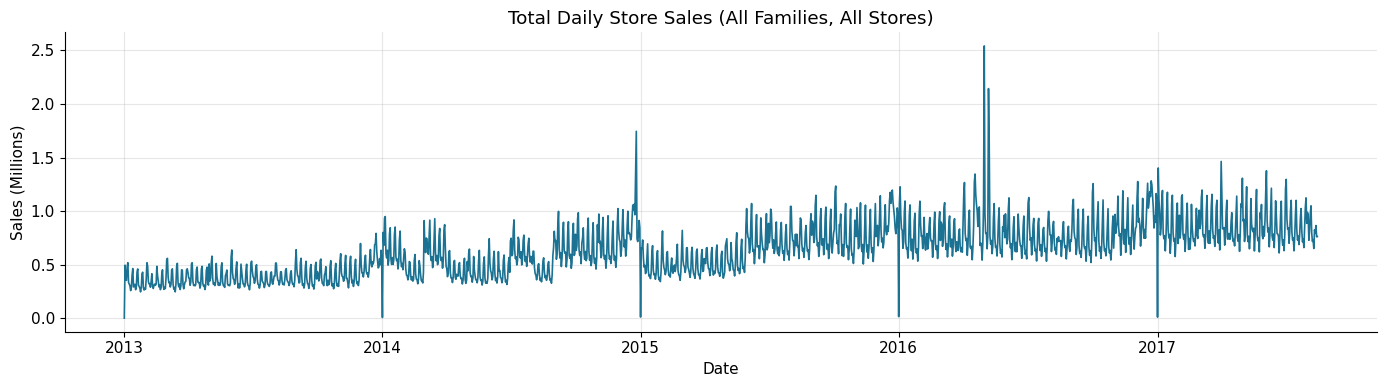

Plot saved: 01_aggregate_sales.png


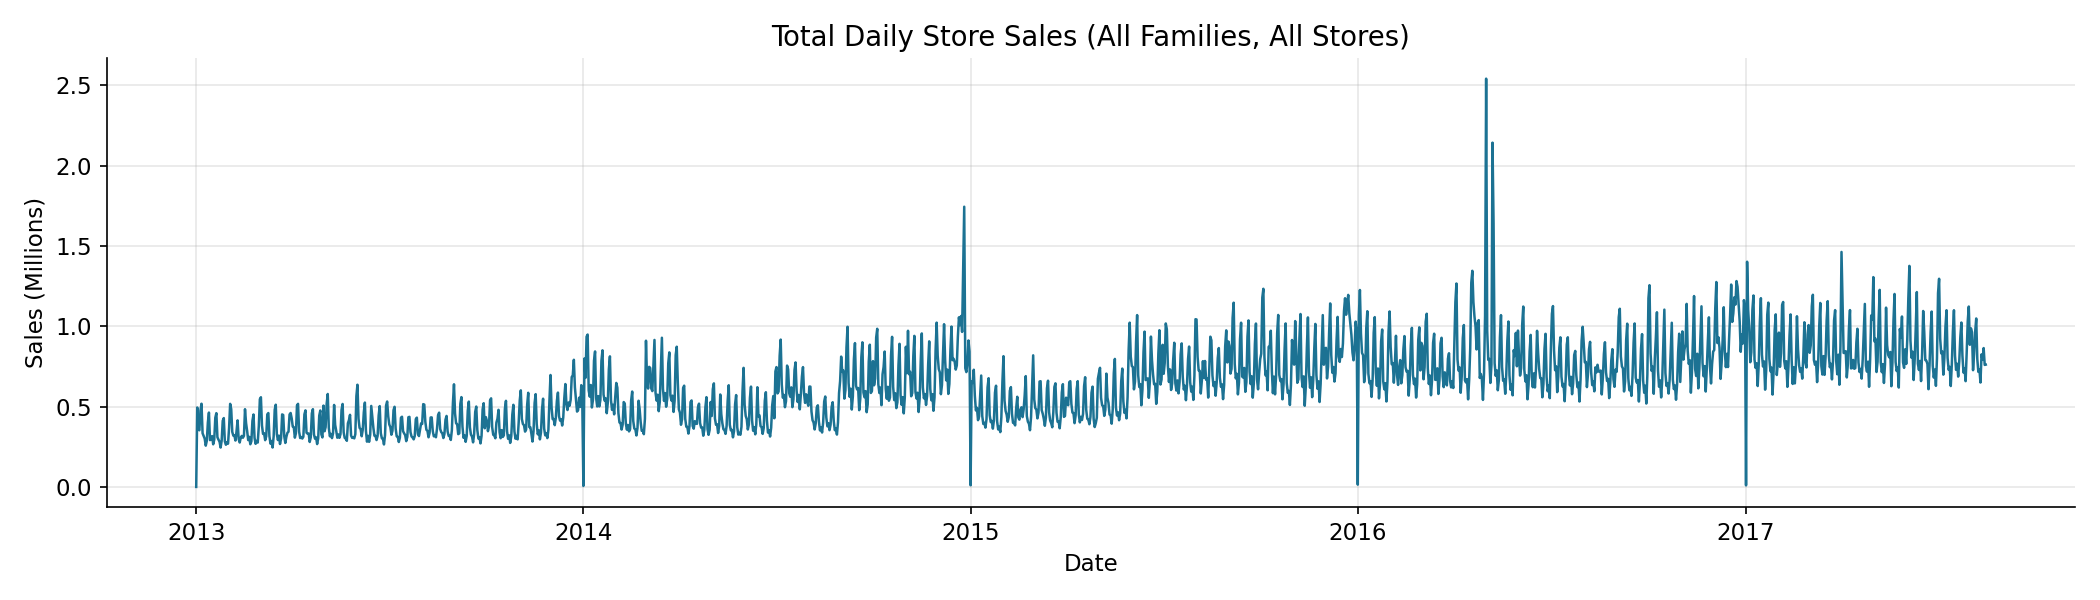

In [23]:
# Ensure agg, family_dict, top_families exist
try:
    _ = agg
    _ = family_dict
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

# 4.1 Total Sales Over Time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(agg.index, agg["sales"] / 1e6, color=PALETTE[0], lw=1.2)
ax.set(title="Total Daily Store Sales (All Families, All Stores)", xlabel="Date", ylabel="Sales (Millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
fig.savefig(PLOTS_DIR / "01_aggregate_sales.png", dpi=150)
plt.show()
print("Plot saved: 01_aggregate_sales.png")
try:
    display(Image(str(PLOTS_DIR / "01_aggregate_sales.png")))
except Exception:
    pass

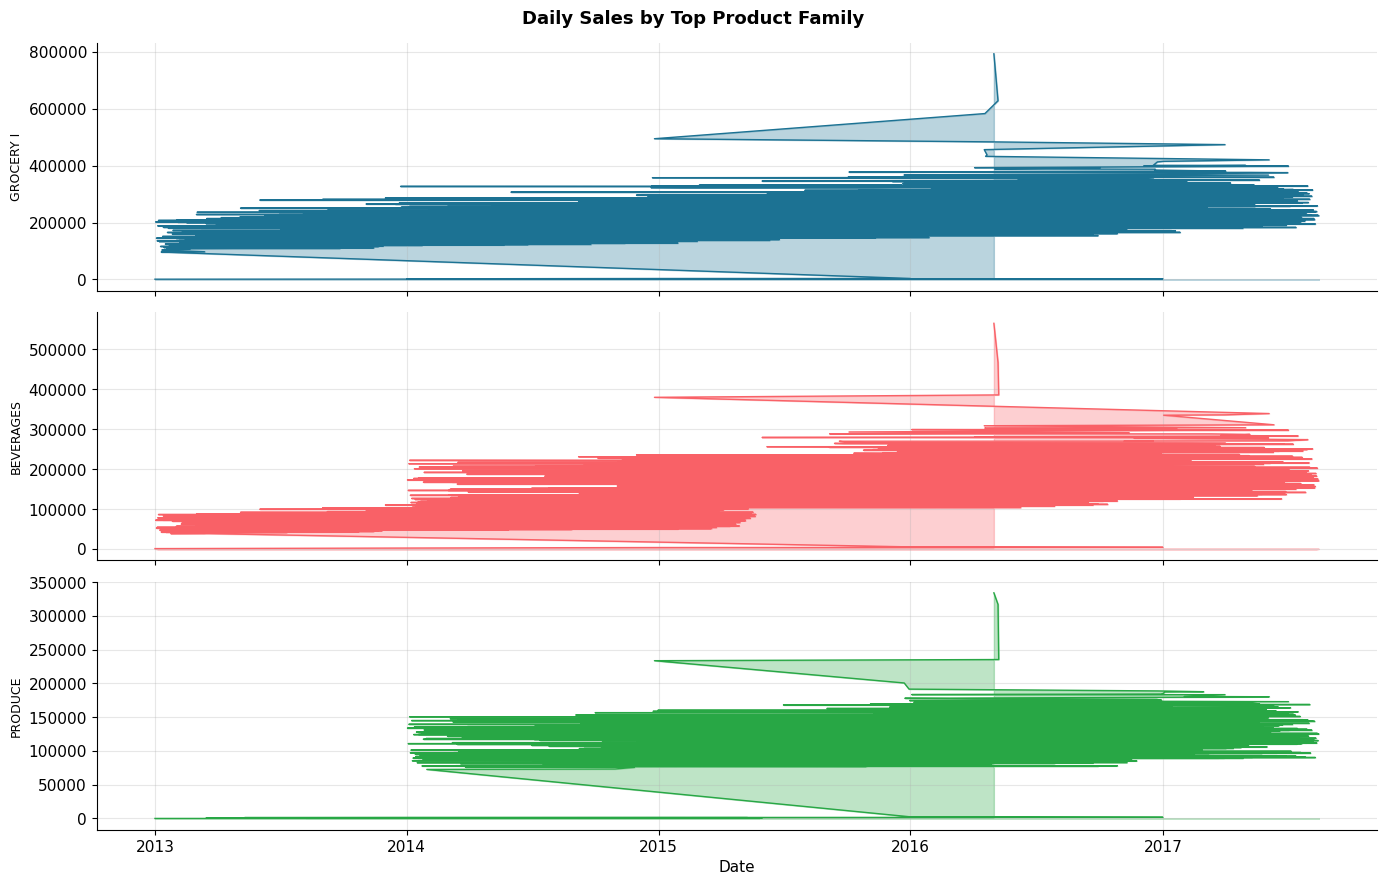

Plot saved: 02_family_sales.png


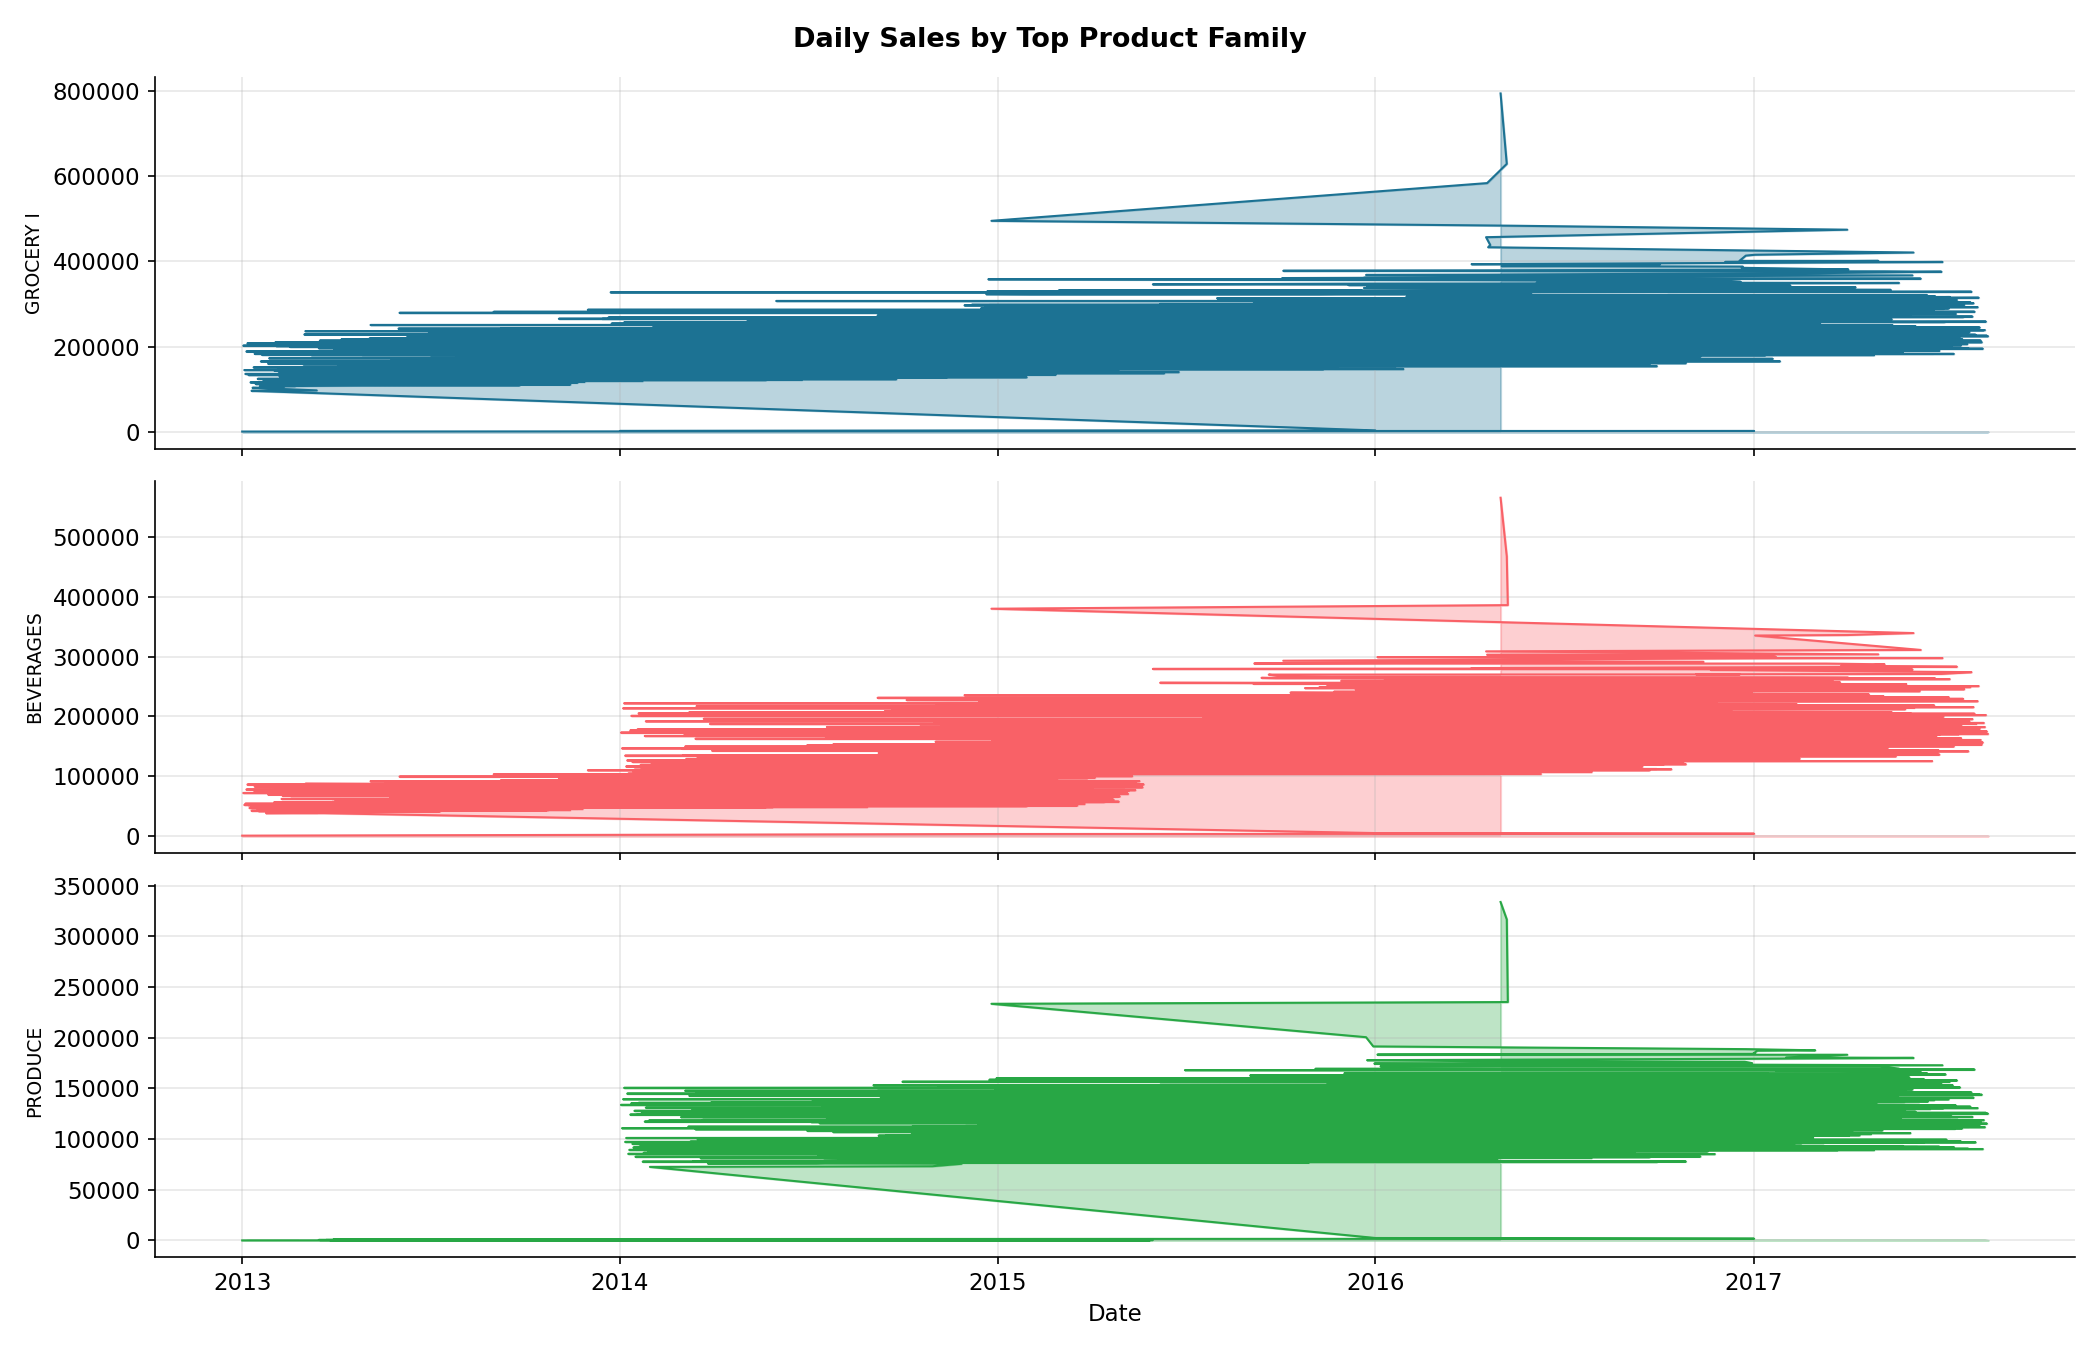

In [24]:
# 4.2 Sales by Product Family (ensure data if needed)
try:
    _ = agg
    _ = family_dict
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

fig, axes = plt.subplots(len(top_families), 1, figsize=(14, 3*len(top_families)), sharex=True)
for ax, fam, color in zip(axes, top_families, PALETTE):
    s = family_dict[fam]
    ax.fill_between(s.index, s.values, alpha=0.3, color=color)
    ax.plot(s.index, s.values, color=color, lw=1)
    ax.set_ylabel(fam, fontsize=9)
axes[-1].set_xlabel("Date")
fig.suptitle("Daily Sales by Top Product Family", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "02_family_sales.png", dpi=150)
plt.show()
print("Plot saved: 02_family_sales.png")
try:
    display(Image(str(PLOTS_DIR / "02_family_sales.png")))
except Exception:
    pass

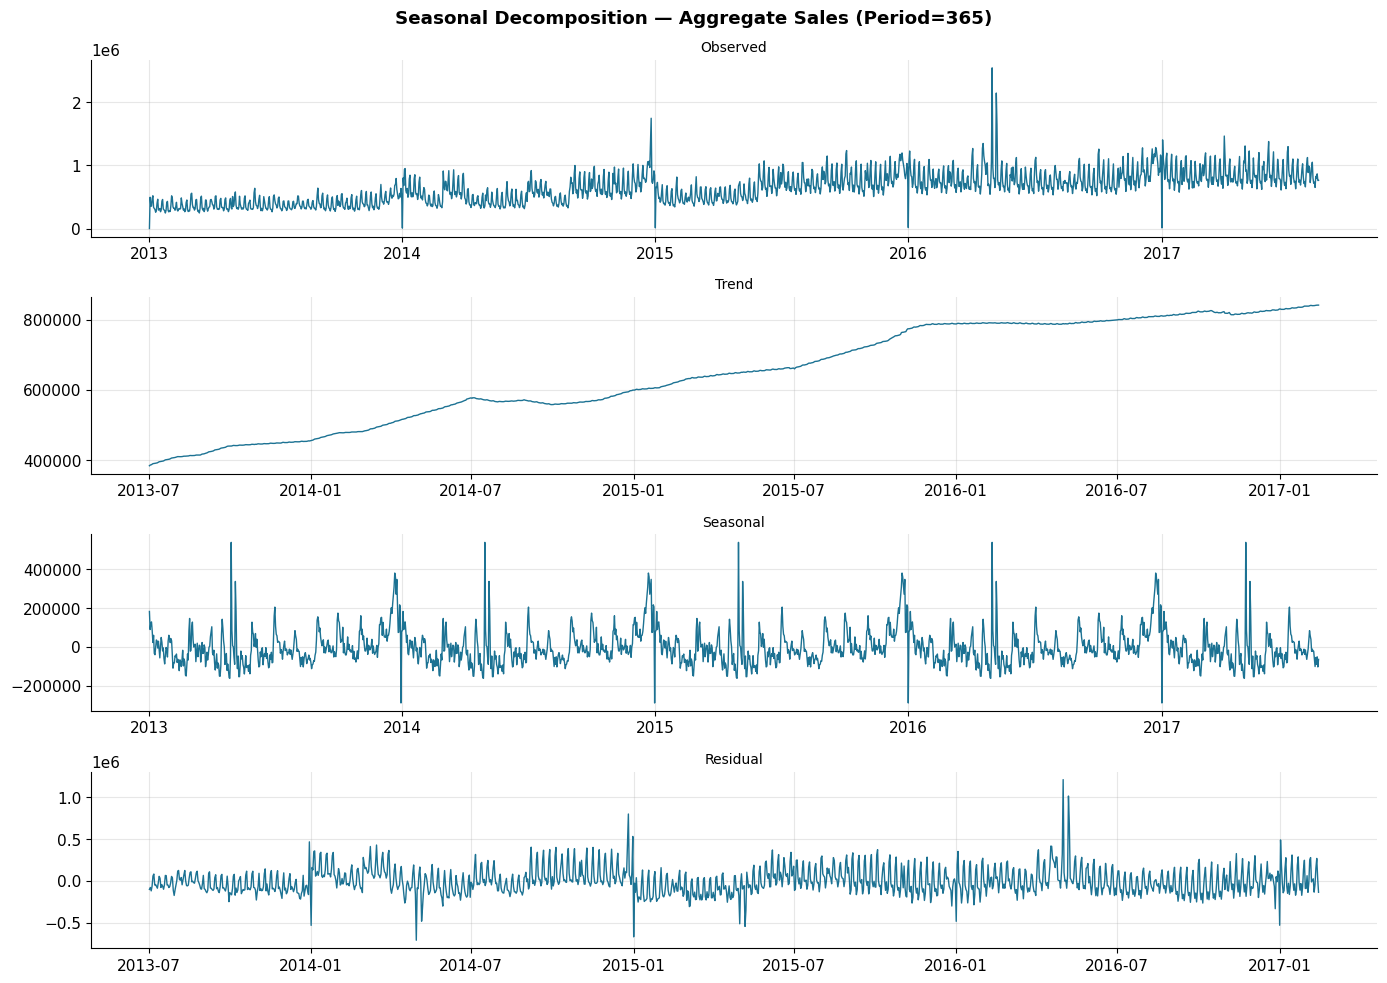

Plot saved: 03_decomposition.png


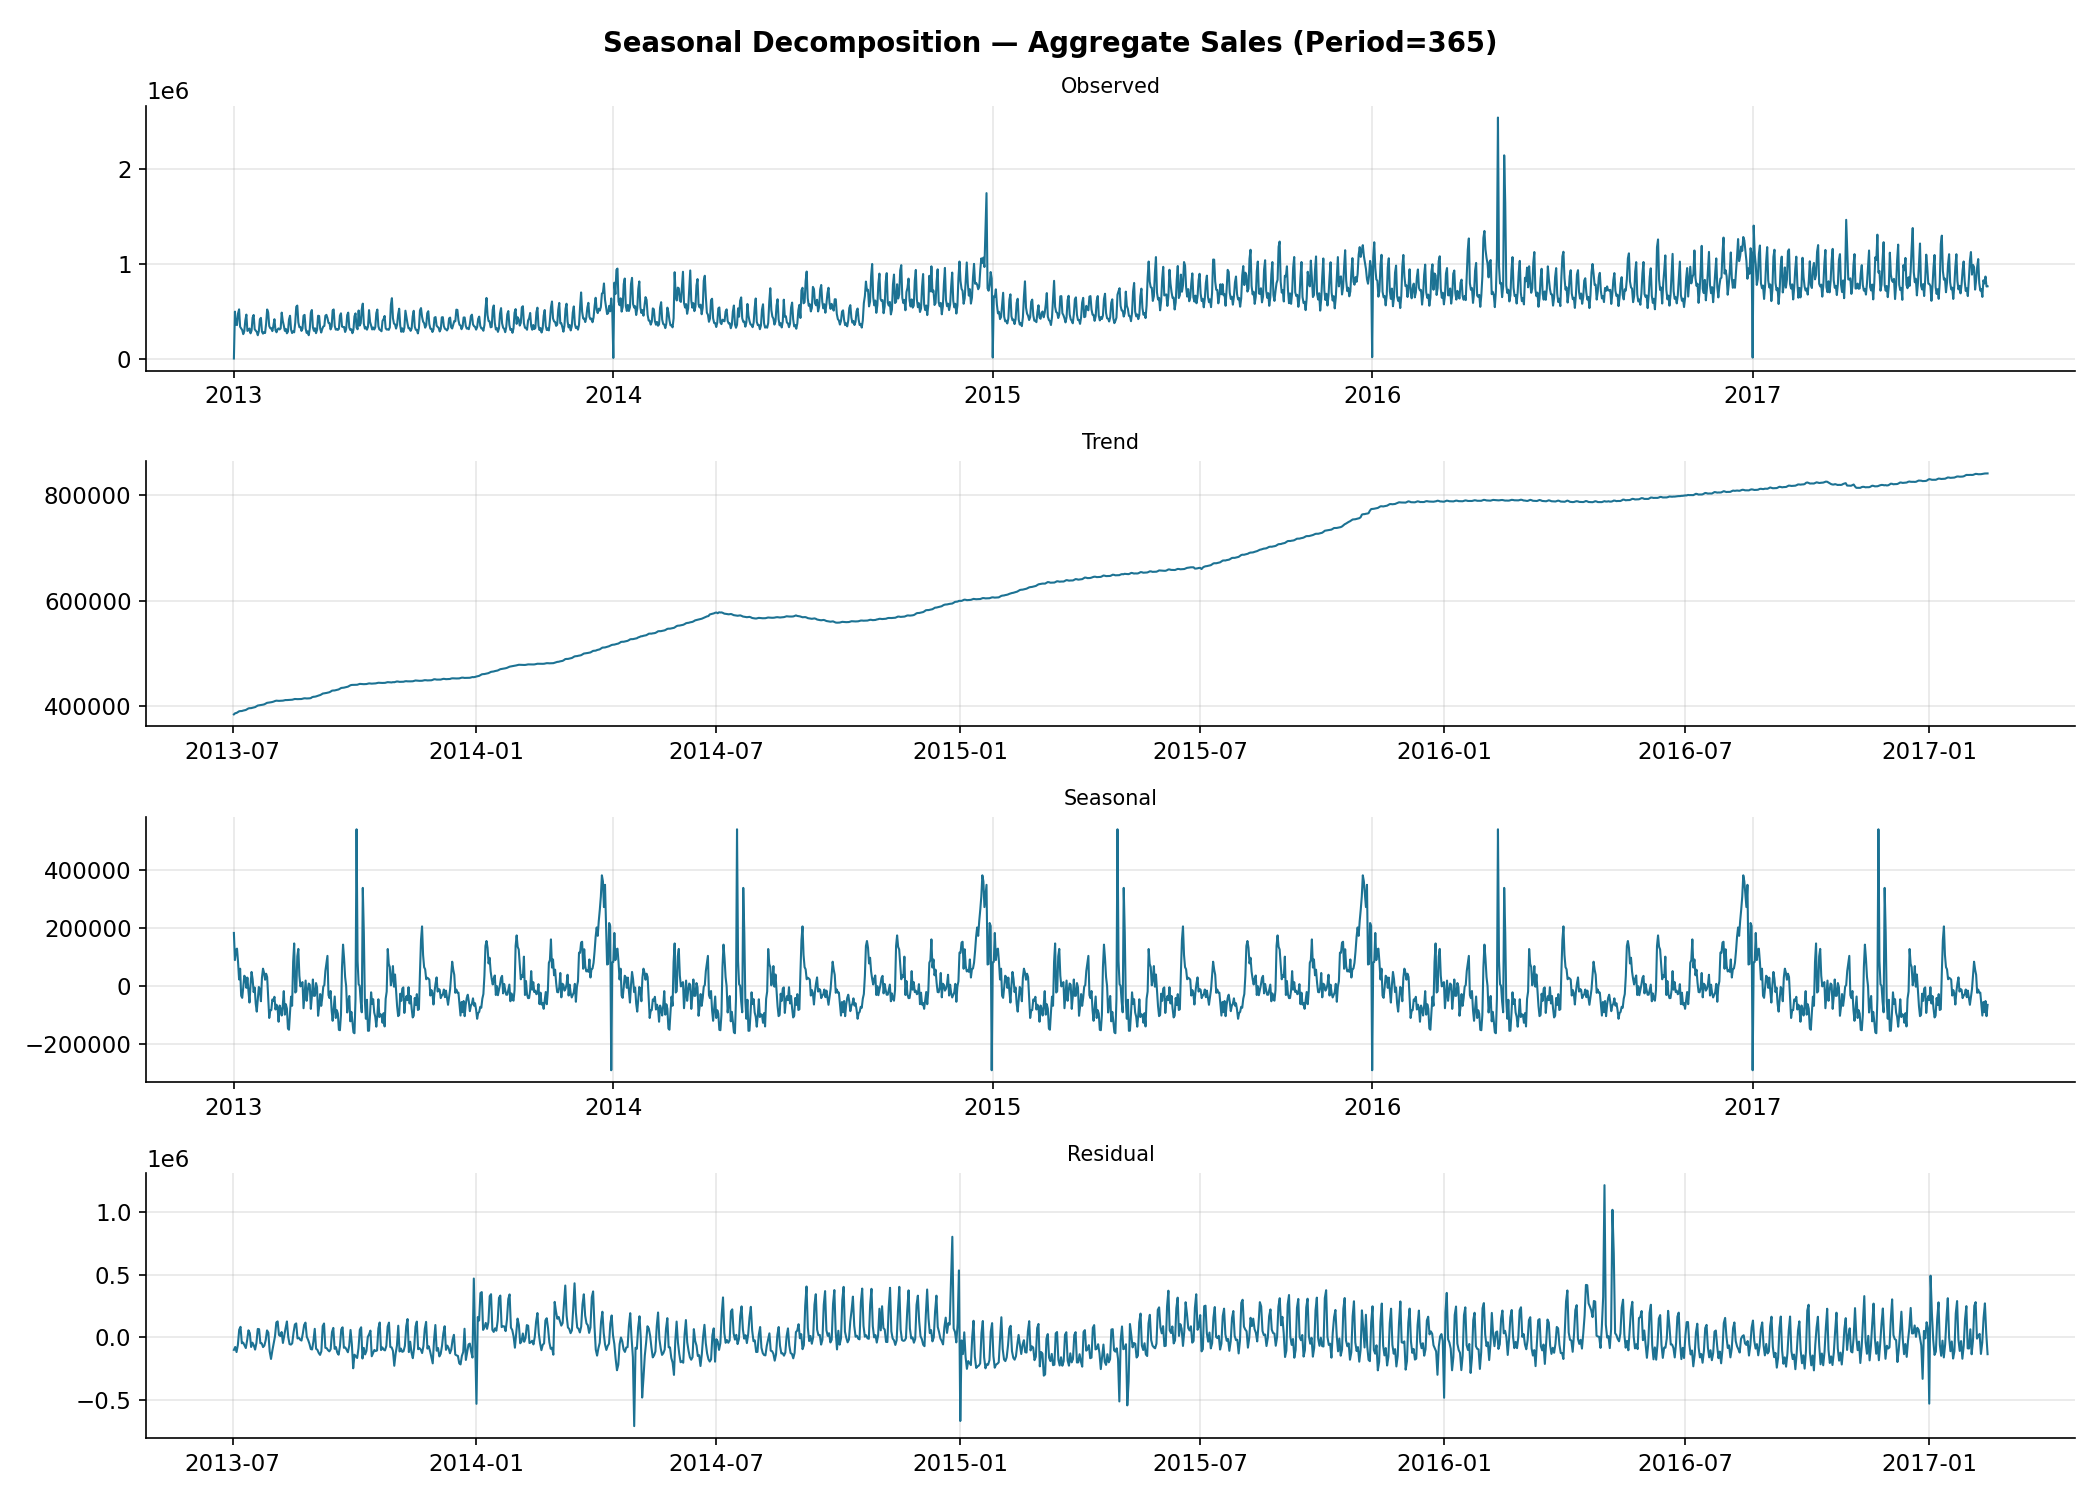

In [25]:
# 4.3 Seasonal Decomposition (ensure data if needed)
try:
    _ = agg
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

decomp = seasonal_decompose(agg["sales"].dropna(), model="additive", period=365)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
titles = ["Observed", "Trend", "Seasonal", "Residual"]
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
for ax, comp, title in zip(axes, components, titles):
    ax.plot(comp.index, comp.values, color=PALETTE[0], lw=1)
    ax.set_title(title, fontsize=10)
fig.suptitle("Seasonal Decomposition — Aggregate Sales (Period=365)", fontweight="bold")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "03_decomposition.png", dpi=150)
plt.show()
print("Plot saved: 03_decomposition.png")
try:
    display(Image(str(PLOTS_DIR / "03_decomposition.png")))
except Exception:
    pass

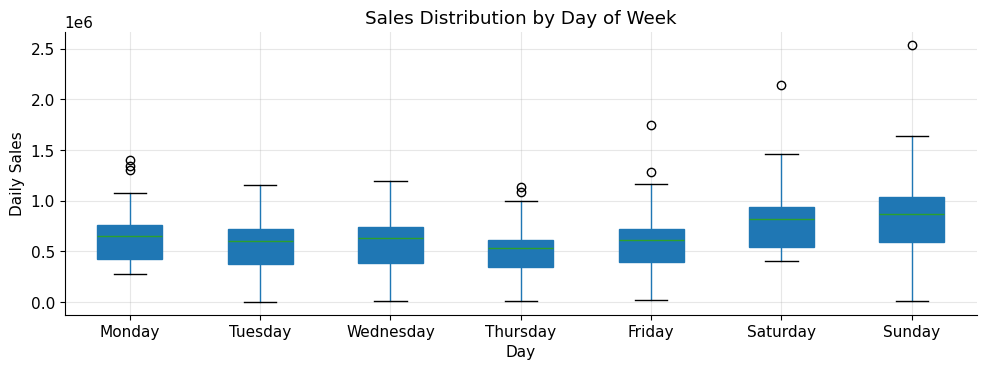

Plot saved: 04_weekly_pattern.png


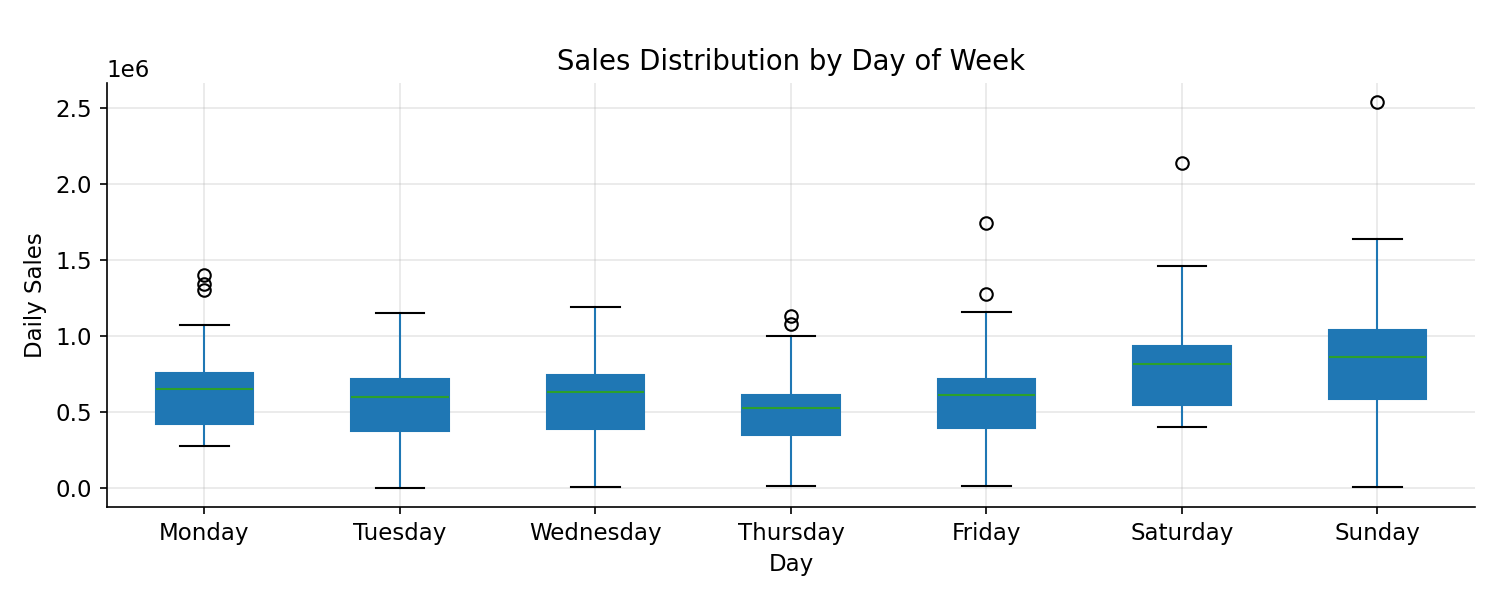

In [26]:
# 4.4 Day-of-week distribution (box plot) (ensure data if needed)
try:
    _ = agg
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

tmp = agg.copy().reset_index()
tmp["day_name"] = pd.to_datetime(tmp["date"]).dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots(figsize=(10, 4))
tmp["day_name"] = pd.Categorical(tmp["day_name"], categories=day_order, ordered=True)
tmp.boxplot(column="sales", by="day_name", ax=ax, patch_artist=True)
ax.set(title="Sales Distribution by Day of Week", xlabel="Day", ylabel="Daily Sales")
plt.suptitle("")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "04_weekly_pattern.png", dpi=150)
plt.show()
print("Plot saved: 04_weekly_pattern.png")
try:
    display(Image(str(PLOTS_DIR / "04_weekly_pattern.png")))
except Exception:
    pass

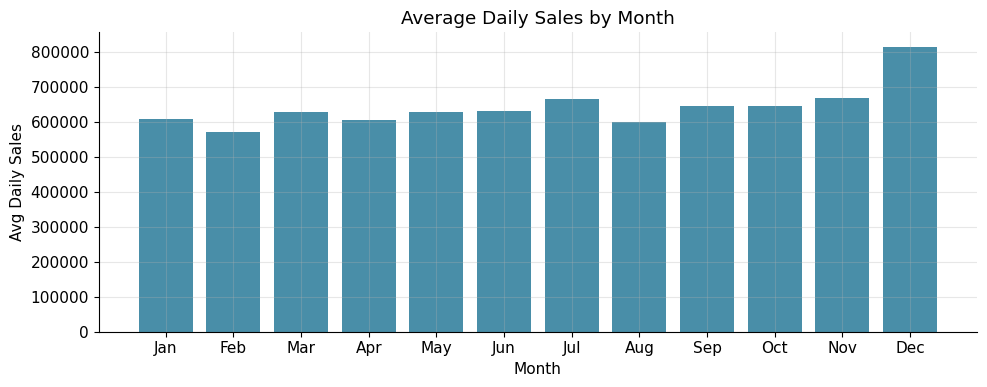

Plot saved: 05_monthly_pattern.png


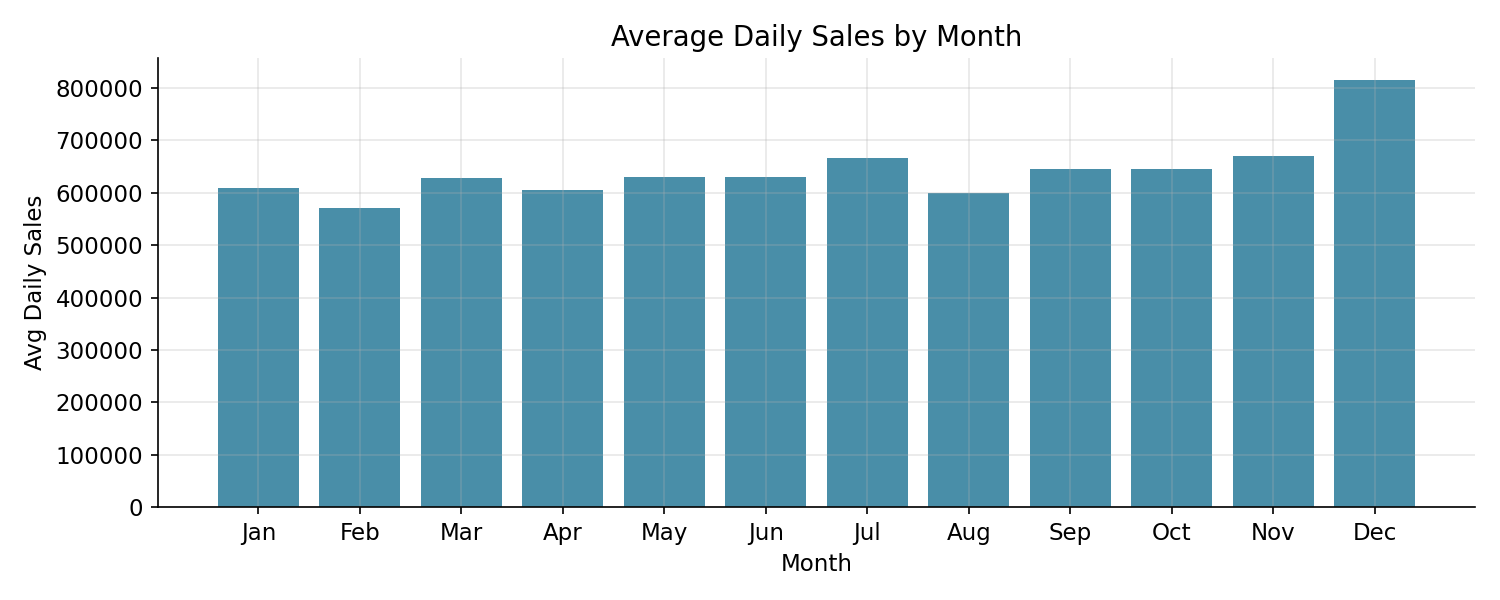

In [27]:
# 4.5 Monthly average sales (ensure data if needed)
try:
    _ = agg
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

tmp = agg.copy().reset_index()
tmp["month"] = pd.to_datetime(tmp["date"]).dt.month
monthly = tmp.groupby("month")["sales"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index, monthly.values, color=PALETTE[0], alpha=0.8)
ax.set(title="Average Daily Sales by Month", xlabel="Month", ylabel="Avg Daily Sales",
       xticks=range(1,13), xticklabels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
fig.savefig(PLOTS_DIR / "05_monthly_pattern.png", dpi=150)
plt.show()
print("Plot saved: 05_monthly_pattern.png")
try:
    display(Image(str(PLOTS_DIR / "05_monthly_pattern.png")))
except Exception:
    pass

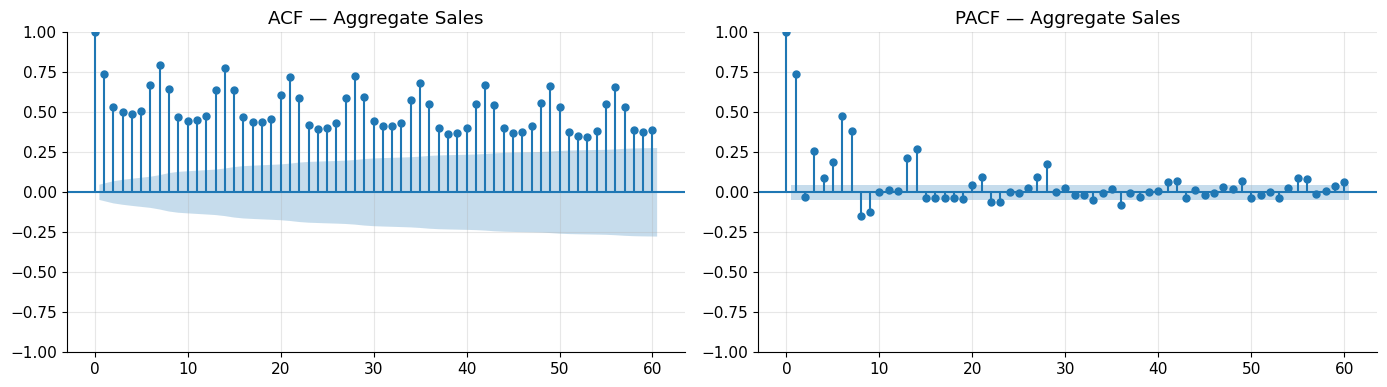

Plot saved: 06_acf_pacf.png


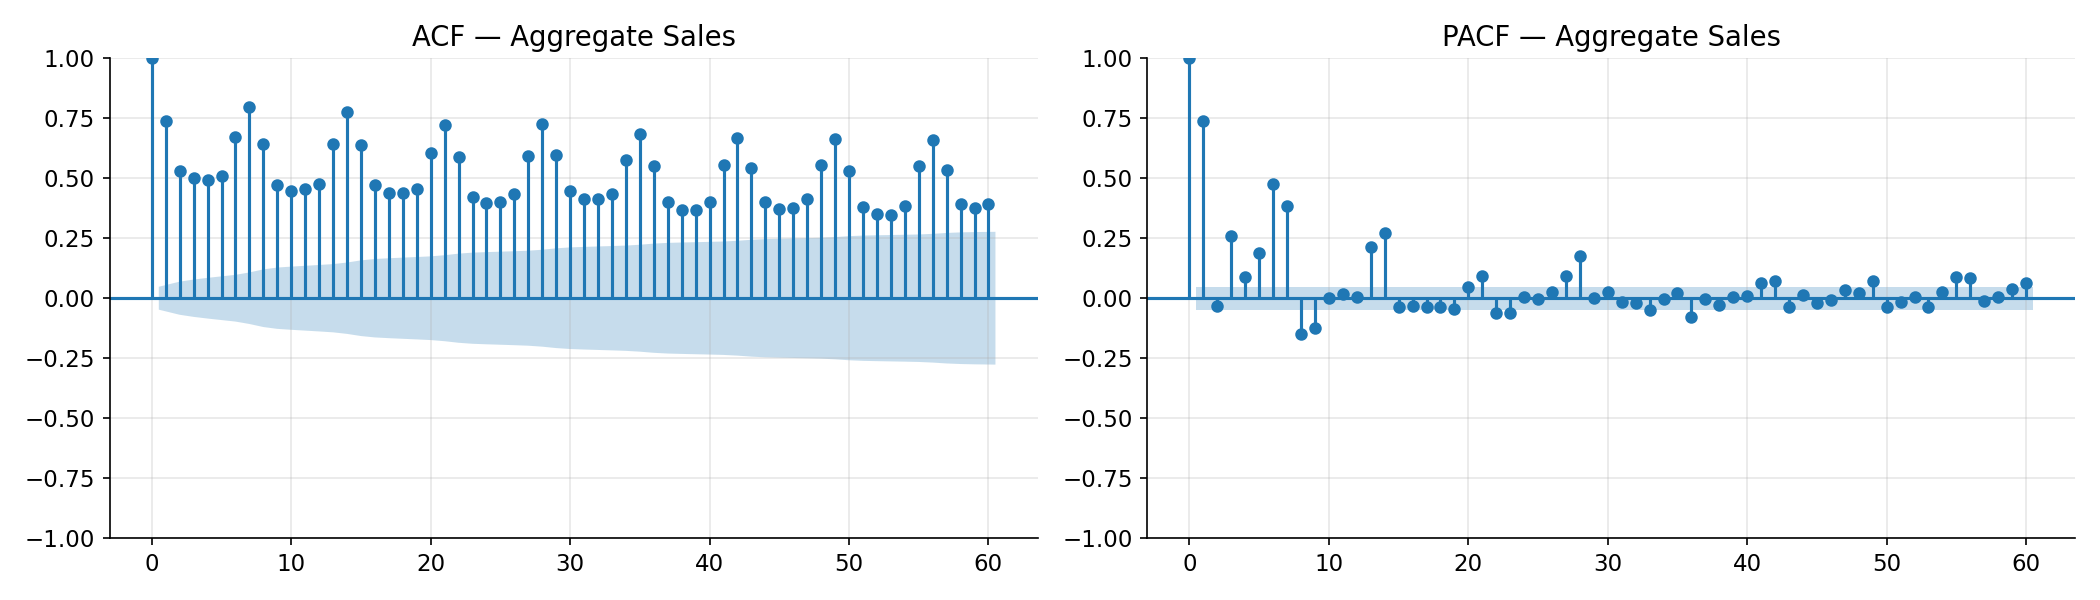

In [28]:
# 4.6 ACF / PACF (ensure data if needed)
try:
    _ = agg
except NameError:
    try:
        _ = df
    except NameError:
        if Path("./data/train.csv").exists():
            train, test, stores, oil, hol = load_data("./data")
        else:
            train, test, stores, oil, hol = generate_synthetic_data()
        df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(agg["sales"].dropna(), lags=60, ax=axes[0], title="ACF — Aggregate Sales")
plot_pacf(agg["sales"].dropna(), lags=60, ax=axes[1], title="PACF — Aggregate Sales", method="ywm")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "06_acf_pacf.png", dpi=150)
plt.show()
print("Plot saved: 06_acf_pacf.png")
try:
    display(Image(str(PLOTS_DIR / "06_acf_pacf.png")))
except Exception:
    pass

In [29]:
# DAILY TOTAL TARGET SERIES (y_total_daily)
# Aggregate daily total sales across all stores and families from agg

y_total_daily = agg["sales"].sort_index().asfreq("D")
print(f"Total daily series: {len(y_total_daily)} days, "
      f"{y_total_daily.index.min().date()} → {y_total_daily.index.max().date()}")

Total daily series: 1688 days, 2013-01-01 → 2017-08-15


### 🔍 Structural Break Check (2013 vs 2014+)

We inspect the total daily series for level shifts between the initial year (2013) and the remainder (2014–2017).

We then define:

- `y_total_daily_full`: full 2013–2017 daily series
- `y_total_daily_post`: post-break (2014–2017), used as the **default** for modeling.

2013 stats:
  Mean: 385,767  |  Std: 97,260

2014–2017 stats:
  Mean: 710,046  |  Std: 224,489


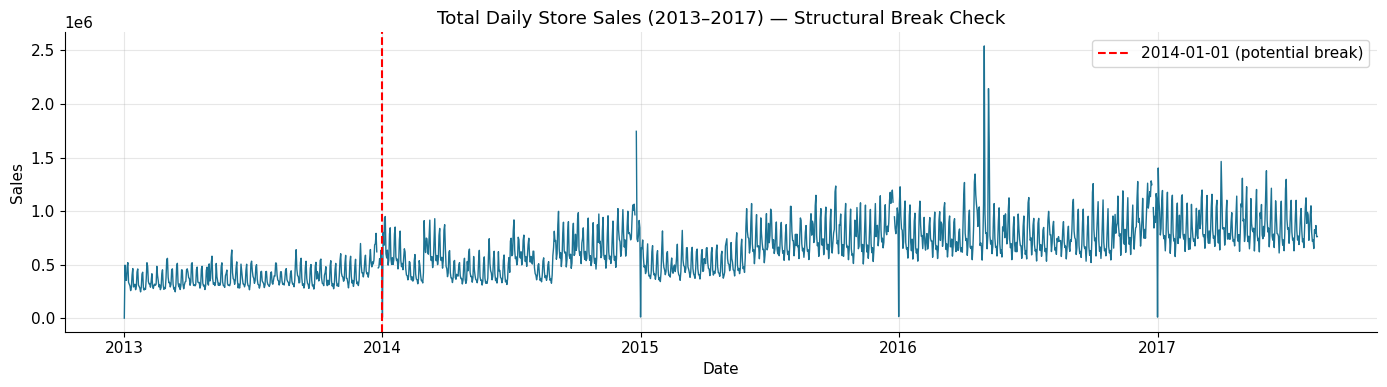


Full sample: 1688 days
Post-break (2014+): 1323 days


In [30]:
# Structural break check on total daily sales

total_daily = y_total_daily  # from earlier cell

mask_2013 = total_daily.index.year == 2013
total_2013 = total_daily[mask_2013]
total_post = total_daily[~mask_2013]

print("2013 stats:")
print(f"  Mean: {total_2013.mean():,.0f}  |  Std: {total_2013.std():,.0f}")
print("\n2014–2017 stats:")
print(f"  Mean: {total_post.mean():,.0f}  |  Std: {total_post.std():,.0f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(total_daily.index, total_daily.values, color=PALETTE[0], lw=1.0)
ax.axvline(pd.Timestamp("2014-01-01"), color="red", linestyle="--", lw=1.5,
           label="2014-01-01 (potential break)")
ax.set_title("Total Daily Store Sales (2013–2017) — Structural Break Check")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

# Define full vs post-break targets
y_total_daily_full = total_daily.copy()
y_total_daily_post = total_daily[total_daily.index >= "2014-01-01"].copy()

print(f"\nFull sample: {len(y_total_daily_full)} days")
print(f"Post-break (2014+): {len(y_total_daily_post)} days")

In [31]:
# --- 4.7 Stationarity tests (self-contained: builds agg if not already in scope) ---
try:
    _ = agg
except NameError:
    from pathlib import Path
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()
    df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
series = agg["sales"].dropna()
adf_stat, adf_p, *_ = adfuller(series)
print("\n=== Stationarity Tests ===")
print(f"  ADF  statistic: {adf_stat:.4f}  p-value: {adf_p:.4f}")
if adf_p < 0.05:
    print("  -> Series is stationary (ADF rejects unit root)")
else:
    print("  -> Series may be non-stationary; differencing recommended")
print("\nEDA complete.")


=== Stationarity Tests ===
  ADF  statistic: -2.6956  p-value: 0.0748
  -> Series may be non-stationary; differencing recommended

EDA complete.


---

## ✂️ 5. TRAIN / VALIDATION SPLIT

Chronological split: hold out the **last 30 days** as validation.  
No random shuffling — time series must be split in order.

In [32]:
def train_val_split(series, val_days=30):
    """Hold out last `val_days` observations as validation set."""
    cutoff = series.index[-1] - pd.Timedelta(days=val_days)
    train  = series[series.index <= cutoff]
    val    = series[series.index >  cutoff]
    print(f"Training:   {train.index.min().date()} → {train.index.max().date()} ({len(train)} obs)")
    print(f"Validation: {val.index.min().date()}   → {val.index.max().date()} ({len(val)} obs)")
    return train, val

In [33]:
# Unified train/test split helper for daily series

def make_train_test(series, mode="last30"):
    """Create chronological train/test splits for a daily series.

    mode:
      - "last30": last 30 days used as test
      - "80_20": 80%/20% split, evaluating only first 30 days of test
    """
    series = series.sort_index()

    if mode == "last30":
        return train_val_split(series, val_days=30)

    if mode == "80_20":
        split_idx = int(0.8 * len(series))
        y_train = series.iloc[:split_idx]
        y_test_full = series.iloc[split_idx:]
        y_test = y_test_full.iloc[:30]
        print(f"80/20 split: train={len(y_train)} days, test window={len(y_test)} days (first 30)")
        return y_train, y_test

    raise ValueError("mode must be 'last30' or '80_20'")

# Choose split mode for daily total-series modeling
SPLIT_MODE = "last30"   # or "80_20"
print(f"Daily modeling split mode: {SPLIT_MODE}")

Daily modeling split mode: last30


In [34]:
# DAILY REGRESSORS for total series: promotions and holidays

from pathlib import Path

# Ensure df exists; if not, rebuild from raw data
try:
    df
except NameError:
    print("df not found in memory — rebuilding from raw data.")
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()
    df = preprocess(train, stores, oil, hol)

# Now df should exist; build daily regressors
daily_sales = df.groupby("date")["sales"].sum().sort_index().asfreq("D")
daily_promo = df.groupby("date")["onpromotion"].sum().sort_index().asfreq("D").fillna(0)
daily_holiday_flag = df.groupby("date")["is_holiday"].max().sort_index().asfreq("D").fillna(0).astype(int)

print("Daily regressors established (sales, onpromotion, holiday flag).")

Daily regressors established (sales, onpromotion, holiday flag).


### 📈 Daily models on total sales (post-break, 30-day horizon)

We now fit ETS, ARIMA, and Prophet on the **post-break** total daily series (`y_total_daily_post`),
using a consistent 30-day test window and the same split mode (`SPLIT_MODE`).

In [35]:
# Daily ETS wrapper
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def fit_ets_daily(y_train, horizon):
    model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=7,
    )
    res = model.fit(optimized=True)
    fc = res.forecast(horizon)

    resid_std = res.resid.std()
    z = 1.96
    lower = fc - z * resid_std
    upper = fc + z * resid_std

    return res, fc, lower, upper


# Daily ARIMA wrapper
from statsmodels.tsa.statespace.sarimax import SARIMAX


def fit_arima_daily(y_train, horizon):
    model = SARIMAX(
        y_train,
        order=(2, 1, 2),
        seasonal_order=(1, 0, 0, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    fc_res = res.get_forecast(steps=horizon)
    fc = fc_res.predicted_mean
    ci = fc_res.conf_int()
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]
    return res, fc, lower, upper


# Daily Prophet wrapper

def fit_prophet_daily(y_train, horizon, label="Total (post-break)"):
    if not PROPHET_AVAILABLE:
        print("Prophet not installed — skipping daily Prophet model.")
        return None, None, None, None

    train_idx = y_train.index
    train_df = pd.DataFrame({
        "ds": train_idx,
        "y": y_train.values,
        "onpromo": daily_promo.loc[train_idx].values,
        "holiday": daily_holiday_flag.loc[train_idx].values,
    })

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,
    )

    m.add_regressor("onpromo")
    m.add_regressor("holiday")

    try:
        m.add_country_holidays(country_name="EC")
    except Exception:
        pass

    m.fit(train_df)

    future = m.make_future_dataframe(periods=horizon, freq="D")
    future = future.set_index("ds")
    future["onpromo"] = daily_promo.reindex(future.index).fillna(0)
    future["holiday"] = daily_holiday_flag.reindex(future.index).fillna(0)
    future = future.reset_index()

    fc = m.predict(future)
    fc_tail = fc.tail(horizon).set_index("ds")

    yhat = fc_tail["yhat"]
    lower = fc_tail["yhat_lower"]
    upper = fc_tail["yhat_upper"]

    return m, yhat, lower, upper

In [36]:
# Run daily models on post-break total series

# 1) Ensure evaluate() exists locally so this cell is self-contained
try:
    evaluate
except NameError:
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    def mape(actual, forecast):
        """Mean Absolute Percentage Error, ignoring zeros."""
        actual, forecast = np.array(actual), np.array(forecast)
        mask = actual != 0
        return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100

    def evaluate(actual, forecast, model_name="Model"):
        mae_v = mean_absolute_error(actual, forecast)
        rmse_v = np.sqrt(mean_squared_error(actual, forecast))
        mape_v = mape(actual, forecast)
        print(f"  [{model_name}]  MAE={mae_v:,.0f}  RMSE={rmse_v:,.0f}  MAPE={mape_v:.2f}%")
        return {"model": model_name, "MAE": mae_v, "RMSE": rmse_v, "MAPE": mape_v}

# 2) Ensure make_train_test and SPLIT_MODE exist so we can split consistently
try:
    make_train_test
except NameError:
    def make_train_test(series, mode="last_30"):
        """Chronological train/validation split.

        mode="last_30": last 30 days as validation.
        mode="80_20": 80/20 time-based split.
        """
        series = series.sort_index()
        if mode == "last_30":
            split_date = series.index.max() - pd.Timedelta(days=30)
            y_train = series[series.index <= split_date]
            y_val = series[series.index > split_date]
        elif mode == "80_20":
            split_idx = int(len(series) * 0.8)
            y_train = series.iloc[:split_idx]
            y_val = series.iloc[split_idx:]
        else:
            raise ValueError("Unknown mode for make_train_test")
        return y_train, y_val

    SPLIT_MODE = "last_30"

# 3) Ensure y_total_daily_post exists (build it if needed)
try:
    y_total_daily_post
except NameError:
    print("y_total_daily_post not found in memory — rebuilding from raw data.")
    # Load data (preferring real Kaggle data if present)
    from pathlib import Path
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        train, test, stores, oil, hol = generate_synthetic_data()
    df = preprocess(train, stores, oil, hol)
    agg = build_aggregate_series(df)
    y_total_daily_full = agg["sales"].sort_index().asfreq("D")
    # Post-break series (2014 onward)
    y_total_daily_post = y_total_daily_full[y_total_daily_full.index >= "2014-01-01"].dropna()

# 4) Compute and reuse y_train_d, y_test_d for all daily models
y_train_d, y_test_d = make_train_test(y_total_daily_post, mode=SPLIT_MODE)
horizon = len(y_test_d)
print(f"Daily total series modeling: train={len(y_train_d)} days, test={horizon} days")

# --- ETS: metrics + chart ---
ets_res_d, ets_fc_d, ets_lo_d, ets_hi_d = fit_ets_daily(y_train_d, horizon)

m_ets_d = evaluate(y_test_d.values, ets_fc_d.values, model_name="ETS (daily total)")
metrics_ets_df = pd.DataFrame([m_ets_d])
display(metrics_ets_df)

# Plot ETS forecast vs actual for the validation period
plt.figure(figsize=(10, 5))
plt.plot(y_train_d.index, y_train_d, label="Train", color=PALETTE[0])
plt.plot(y_test_d.index, y_test_d, label="Actual (validation)", color=PALETTE[1])
plt.plot(ets_fc_d.index, ets_fc_d, label="ETS forecast", color=PALETTE[2])
if ets_lo_d is not None and ets_hi_d is not None:
    plt.fill_between(ets_lo_d.index, ets_lo_d, ets_hi_d, color=PALETTE[2], alpha=0.2, label="ETS 95% CI")
plt.title("ETS daily model on total sales (post-break)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

Training:   2014-01-01 → 2017-07-16 (1293 obs)
Validation: 2017-07-17   → 2017-08-15 (30 obs)
Daily total series modeling: train=1293 days, test=30 days


ValueError: Input contains NaN.

In [ ]:
# ARIMA daily model on post-break total series

# ARIMA
arima_res_d, arima_fc_d, arima_lo_d, arima_hi_d = fit_arima_daily(y_train_d, horizon)
m_arima_d = evaluate(y_test_d.values, arima_fc_d.values, model_name="ARIMA (daily total)")

# Show metrics for ARIMA only
arima_metrics_df = pd.DataFrame([m_arima_d])
display(arima_metrics_df)

  [ARIMA (daily total)]  MAE=78,593  RMSE=93,810  MAPE=9.62%


,model,MAE,RMSE,MAPE
0,ARIMA (daily total),78592.818769,93810.480805,9.617734


In [ ]:
# Prophet daily model on post-break total series

# Prophet
prophet_m_d, prophet_fc_d, prophet_lo_d, prophet_hi_d = fit_prophet_daily(y_train_d, horizon)
if prophet_m_d is not None:
    m_prophet_d = evaluate(y_test_d.values, prophet_fc_d.values, model_name="Prophet (daily total)")
    prophet_metrics_df = pd.DataFrame([m_prophet_d])
    display(prophet_metrics_df)
else:
    print("Prophet model did not fit successfully; no metrics to display.")

02:38:48 - cmdstanpy - INFO - Chain [1] start processing
02:38:49 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet (daily total)]  MAE=86,787  RMSE=108,402  MAPE=10.48%


,model,MAE,RMSE,MAPE
0,Prophet (daily total),86786.675987,108401.557033,10.483036


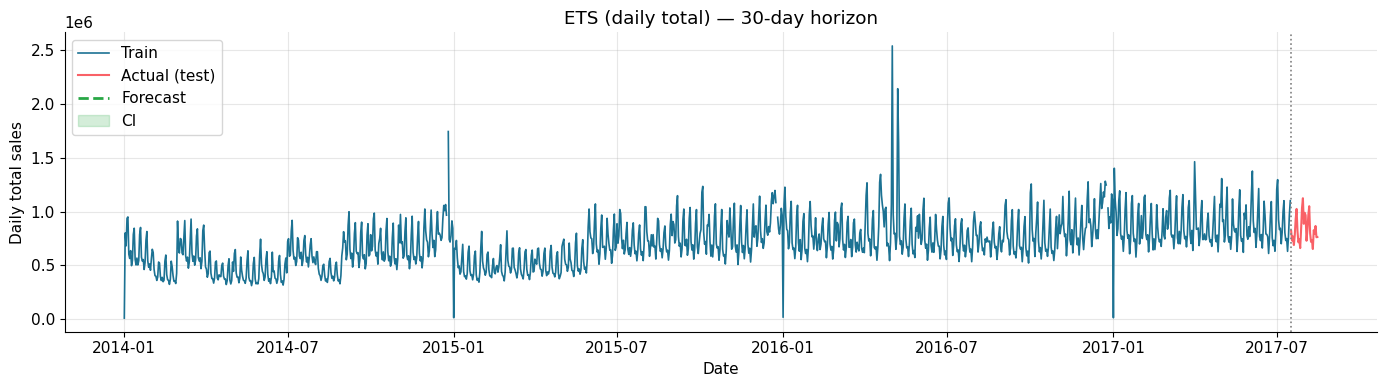

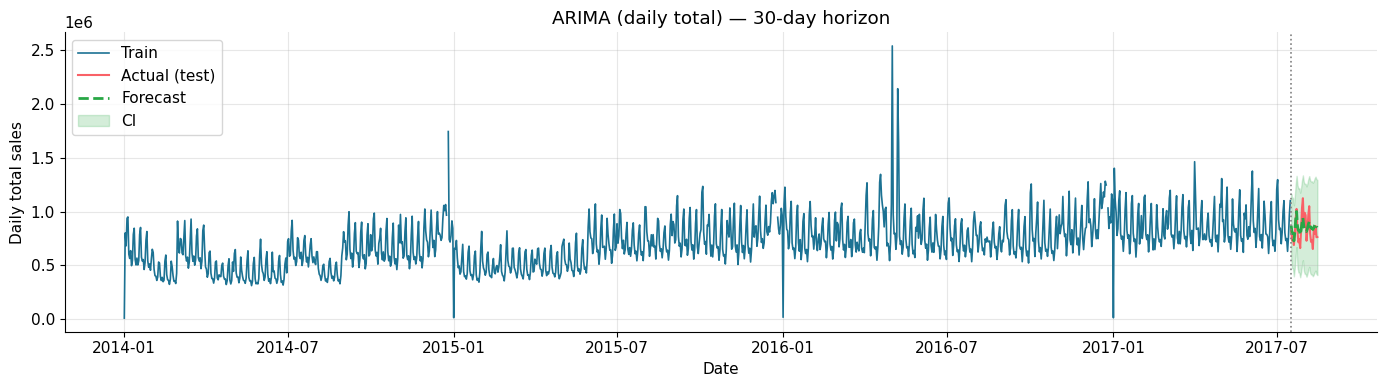

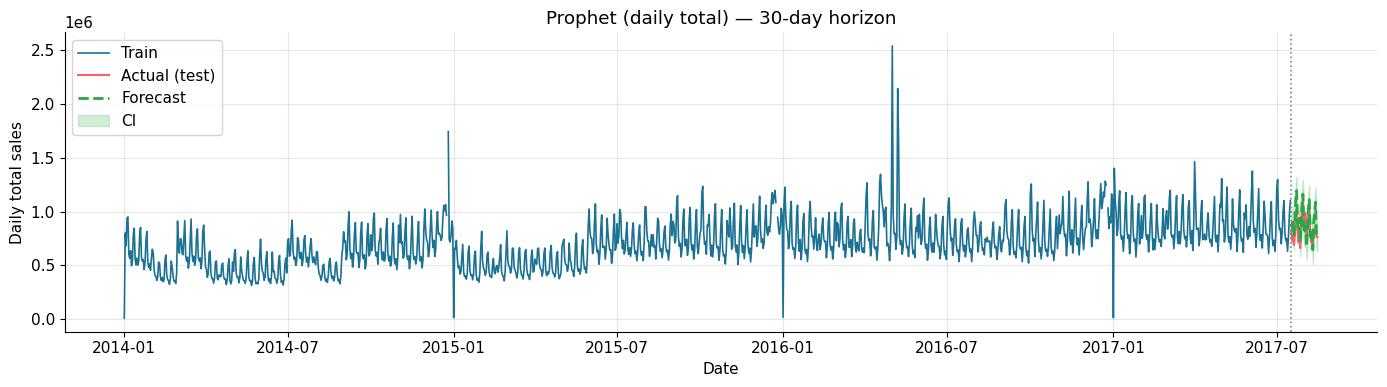

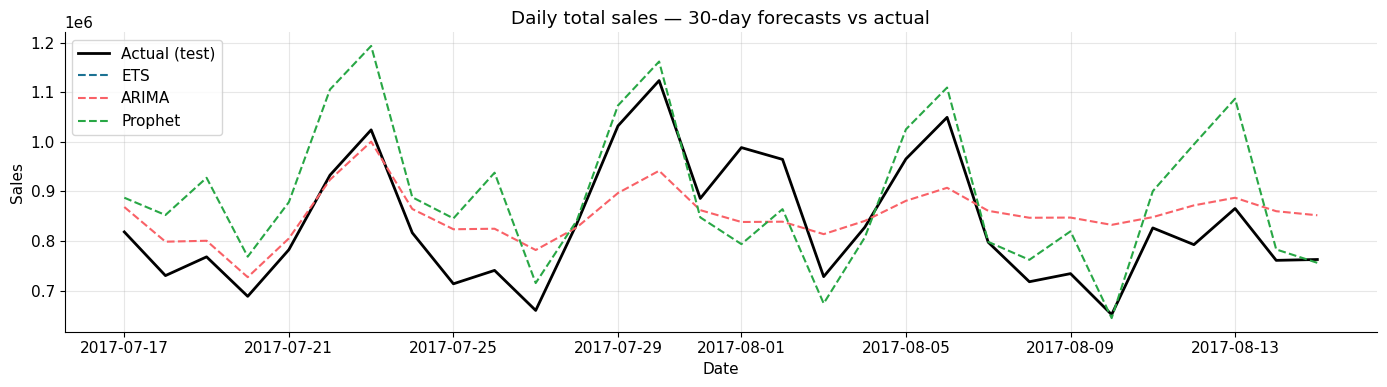

In [ ]:
# Helper to plot a single model's daily forecast with CI

def plot_daily_model(y_train, y_test, fc, lo, hi, title):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_train.index, y_train.values, color=PALETTE[0], lw=1.2, label="Train")
    ax.plot(y_test.index, y_test.values, color=PALETTE[1], lw=1.5, label="Actual (test)")
    ax.plot(y_test.index, fc.values, color=PALETTE[2], lw=2, linestyle="--", label="Forecast")
    ax.fill_between(y_test.index, lo.values, hi.values, color=PALETTE[2], alpha=0.2, label="CI")
    ax.axvline(y_test.index[0], color="gray", linestyle=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily total sales")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_daily_model(y_train_d, y_test_d, ets_fc_d, ets_lo_d, ets_hi_d,
                 "ETS (daily total) — 30-day horizon")

plot_daily_model(y_train_d, y_test_d, arima_fc_d, arima_lo_d, arima_hi_d,
                 "ARIMA (daily total) — 30-day horizon")

if prophet_m_d is not None:
    plot_daily_model(y_train_d, y_test_d, prophet_fc_d, prophet_lo_d, prophet_hi_d,
                     "Prophet (daily total) — 30-day horizon")

# Combined plot (no CI, just lines)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_d.index, y_test_d.values, color="black", lw=2, label="Actual (test)")
ax.plot(y_test_d.index, ets_fc_d.values, color=PALETTE[0], linestyle="--", lw=1.5, label="ETS")
ax.plot(y_test_d.index, arima_fc_d.values, color=PALETTE[1], linestyle="--", lw=1.5, label="ARIMA")
if prophet_m_d is not None:
    ax.plot(y_test_d.index, prophet_fc_d.values, color=PALETTE[2], linestyle="--", lw=1.5, label="Prophet")

ax.set_title("Daily total sales — 30-day forecasts vs actual")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

### 🔧 Diagnostics for best daily model

We examine ACF/PACF of test residuals and run a simple OLS:

\( \text{residuals} \sim \text{onpromotion} + \text{holiday} \)

This helps check whether promotions and holidays still explain part of the variation left by the model.

In [ ]:
# DIAGNOSTICS for best daily model (lowest MAPE)

best_row = metrics_daily_df.loc[metrics_daily_df["MAPE"].idxmin()]
print("Best daily model by MAPE:", best_row["model"])

if "ETS" in best_row["model"]:
    fc_best = ets_fc_d
elif "ARIMA" in best_row["model"]:
    fc_best = arima_fc_d
else:
    fc_best = prophet_fc_d

resid_test = y_test_d - fc_best

# ACF / PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_test.dropna(), ax=axes[0], lags=30, title="ACF — test residuals")
plot_pacf(resid_test.dropna(), ax=axes[1], lags=30, method="ywm", title="PACF — test residuals")
plt.tight_layout()
plt.show()

# OLS: residuals ~ onpromotion + holiday
import statsmodels.api as sm

X_diag = pd.DataFrame({
    "onpromo": daily_promo.loc[y_test_d.index].values,
    "holiday": daily_holiday_flag.loc[y_test_d.index].astype(int).values,
}, index=y_test_d.index)
X_diag = sm.add_constant(X_diag)

ols_res = sm.OLS(resid_test.values, X_diag.values).fit()
print(ols_res.summary())

NameError: name 'metrics_daily_df' is not defined

### 🌍 Geography / store-level EDA

We briefly explore heterogeneity across stores using `stores.csv` merged into the main `df`.

In [ ]:
# Geography / store-level EDA

df_stores = df.merge(stores, on="store_nbr", how="left")

store_totals = df_stores.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)
top_stores = store_totals.head(10)

print("Top 10 stores by total sales:")
display(top_stores.to_frame("total_sales"))

fig, ax = plt.subplots(figsize=(10, 4))
top_stores.plot(kind="bar", ax=ax, color=PALETTE[0])
ax.set_title("Top 10 stores by total sales")
ax.set_xlabel("Store number")
ax.set_ylabel("Total sales")
plt.tight_layout()
plt.show()

if "type" in df_stores.columns:
    type_totals = df_stores.groupby("type")["sales"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 4))
    type_totals.plot(kind="bar", ax=ax, color=PALETTE[1])
    ax.set_title("Total sales by store type")
    ax.set_xlabel("Store type")
    ax.set_ylabel("Total sales")
    plt.tight_layout()
    plt.show()

### 🎄 Holidays analysis (EDA)

We compare daily sales on holidays vs non-holidays and visualize holiday dates.

In [ ]:
# Holidays analysis EDA

daily_df = df.groupby("date")["sales", "is_holiday"].agg({
    "sales": "sum",
    "is_holiday": "max",
}).sort_index()
daily_df["is_holiday"] = daily_df["is_holiday"].astype(int)

mean_holiday = daily_df.loc[daily_df["is_holiday"] == 1, "sales"].mean()
mean_nonholiday = daily_df.loc[daily_df["is_holiday"] == 0, "sales"].mean()

print(f"Mean sales on holidays:     {mean_holiday:,.0f}")
print(f"Mean sales on non-holidays: {mean_nonholiday:,.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
daily_df["sales"].plot(ax=ax, color=PALETTE[0], lw=0.8)
ax.scatter(
    daily_df.index[daily_df["is_holiday"] == 1],
    daily_df.loc[daily_df["is_holiday"] == 1, "sales"],
    color=PALETTE[1], s=10, label="Holiday",
)
ax.set_title("Daily total sales with holidays highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

### 📢 Promotions analysis (EDA)

We examine how aggregate promotions relate to daily sales.

In [ ]:
# Promotions vs sales EDA

daily_promo_df = df.groupby("date")["sales", "onpromotion"].sum().sort_index()

corr = daily_promo_df["sales"].corr(daily_promo_df["onpromotion"])
print(f"Correlation (daily sales vs daily onpromotion): {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(daily_promo_df["onpromotion"], daily_promo_df["sales"], alpha=0.3, color=PALETTE[2])
ax.set_title("Daily sales vs daily onpromotion")
ax.set_xlabel("Onpromotion (count)")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

threshold = daily_promo_df["onpromotion"].median()
low = daily_promo_df[daily_promo_df["onpromotion"] <= threshold]["sales"].mean()
high = daily_promo_df[daily_promo_df["onpromotion"] > threshold]["sales"].mean()
print(f"Mean sales on low-promo days:  {low:,.0f}")
print(f"Mean sales on high-promo days: {high:,.0f}")

### 📅 Weekly sales (visualization only)

We aggregate total sales weekly for visualization; modeling remains on the daily frequency.

In [ ]:
# Weekly total sales (visualization only)

weekly_total = y_total_daily_full.resample("W").sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_total.index, weekly_total.values, color=PALETTE[0], lw=1.2)
ax.set_title("Weekly total sales (visualization)")
ax.set_xlabel("Week")
ax.set_ylabel("Sales (weekly sum)")
plt.tight_layout()
plt.show()

### 📦 Extension: ETS per top N product families (daily)

As an optional extension, we fit an ETS model per top-N product families on daily data
(post-break, 2014+) and report 30-day validation metrics.

In [ ]:
# ETS per top N product families (daily extension)

topN = 5
family_totals_all = df.groupby("family")["sales"].sum().sort_values(ascending=False)
topN_families = family_totals_all.head(topN).index.tolist()
print(f"Top {topN} families: {topN_families}")

ets_family_rows = []

for fam in topN_families:
    s = (
        df[df["family"] == fam]
        .groupby("date")["sales"].sum()
        .sort_index()
        .asfreq("D")
        .fillna(0)
    )
    # Use post-break period for consistency
    s_post = s[s.index >= "2014-01-01"]
    y_train_f, y_test_f = make_train_test(s_post, mode="last30")
    h = len(y_test_f)
    _, fc_f, lo_f, hi_f = fit_ets_daily(y_train_f, h)
    m_row = evaluate(y_test_f.values, fc_f.values, model_name=f"ETS ({fam})")
    ets_family_rows.append({"family": fam, **{k: v for k, v in m_row.items() if k != "model"}})

ets_family_df = pd.DataFrame(ets_family_rows)
display(ets_family_df)

---

## 🛒 Product-family repair, decomposition & model evaluation

This section shows, for a selected product family:

1. **Repair**: simple outlier-based repair on the daily sales series (per family).
2. **Decomposition**: additive decomposition of the **training** portion only (to avoid leakage).
3. **Models**: ARIMA, ETS, and Prophet fitted on the repaired series with a 30-day validation window.

Run this **after**:

- `Load data & preprocess`
- `Build time series` (so that `family_dict` and `top_families` exist)
- The ARIMA/ETS/Prophet helper functions are already defined above.

Example family for repair/decomposition: GROCERY I
Family series length: 1684 days, from 2013-01-01 to 2017-08-15


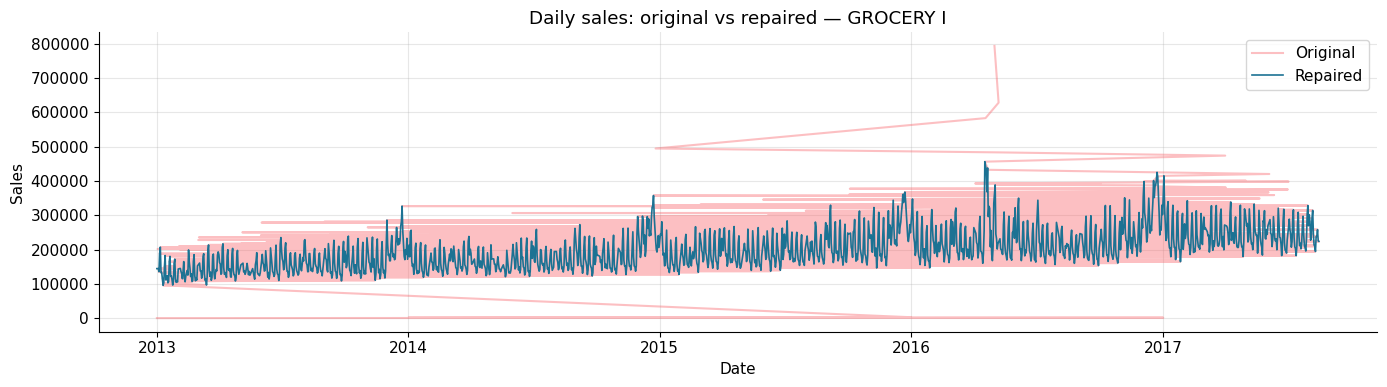

In [ ]:
# Helper: simple outlier-based repair for a daily family series
import numpy as np


def repair_series_rolling(series, window=30, z_thresh=3.0):
    """Repair outliers in a daily series using rolling median and z-scores.

    - series: pd.Series with DatetimeIndex and daily frequency
    - window: rolling window (in days) for local median/scale
    - z_thresh: threshold on standardized residuals to flag outliers
    """
    s = series.sort_index().astype(float).copy()

    # Avoid log of zero by working in log1p space (stabilizes variance)
    logy = np.log1p(s)

    med = logy.rolling(window=window, center=True, min_periods=10).median()
    mad = (logy - med).abs().rolling(window=window, center=True, min_periods=10).median()

    # Robust z-score
    eps = 1e-6
    z = (logy - med) / (mad + eps)

    outliers = z.abs() > z_thresh

    if not outliers.any():
        return s  # nothing to repair

    # Interpolate log-values at outlier positions from neighbors
    logy_repaired = logy.copy()
    logy_repaired[outliers] = np.nan
    logy_repaired = logy_repaired.interpolate(method="time").ffill().bfill()

    repaired = np.expm1(logy_repaired)
    repaired[repaired < 0] = 0
    return repaired


# Choose a family to demonstrate (first in top_families)
example_family = top_families[0]
print(f"Example family for repair/decomposition: {example_family}")

fam_series = family_dict[example_family].copy()
print(f"Family series length: {len(fam_series)} days, from {fam_series.index.min().date()} to {fam_series.index.max().date()}")

# Apply repair
fam_repaired = repair_series_rolling(fam_series)

# Plot original vs repaired
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(fam_series.index, fam_series.values, color=PALETTE[1], alpha=0.4, label="Original")
ax.plot(fam_repaired.index, fam_repaired.values, color=PALETTE[0], lw=1.2, label="Repaired")
ax.set_title(f"Daily sales: original vs repaired — {example_family}")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

Training:   2013-01-01 → 2017-07-16 (1654 obs)
Validation: 2017-07-17   → 2017-08-15 (30 obs)


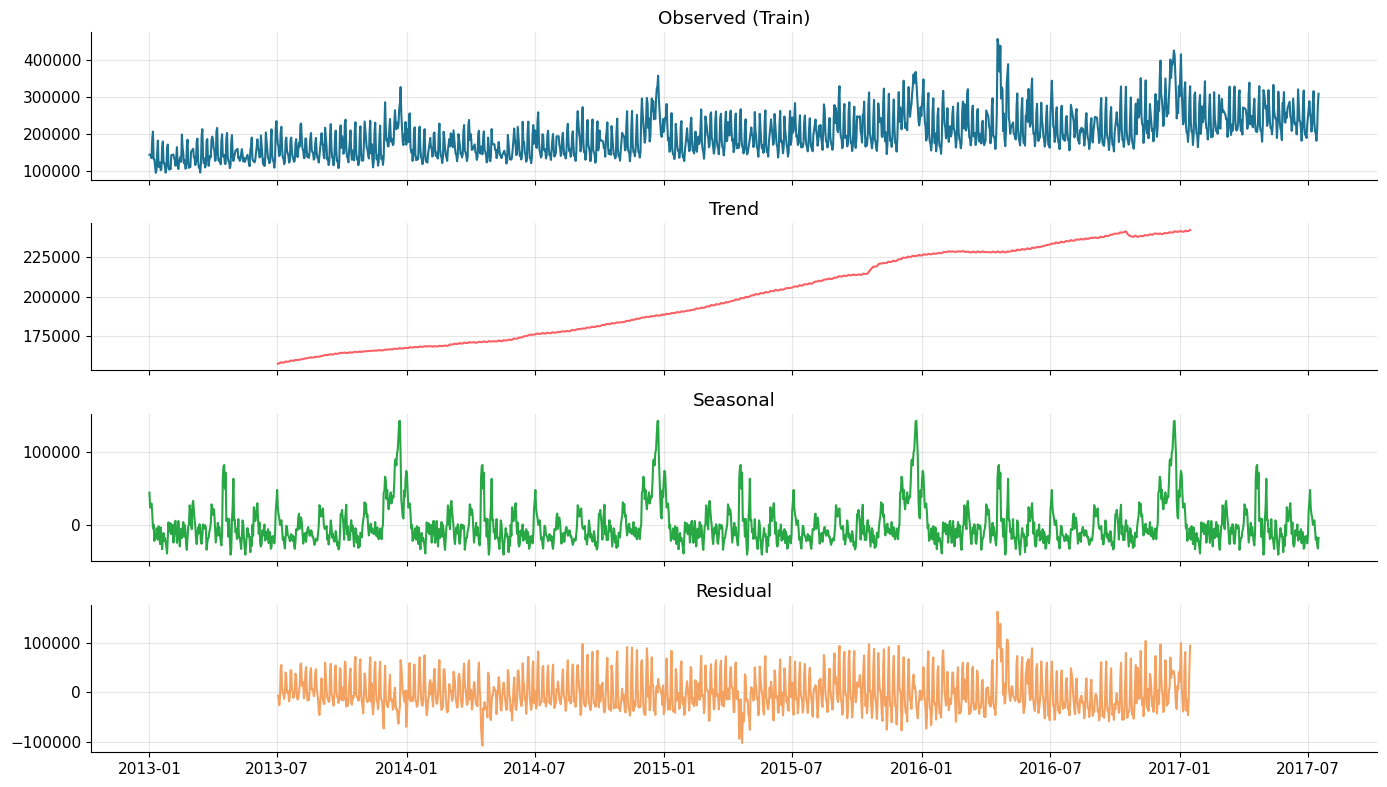

In [ ]:
# Decompose TRAIN portion only (avoid leakage)

# Use same 30-day validation as the rest of the notebook
train_fam, val_fam = train_val_split(fam_repaired, val_days=30)

from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition on TRAIN only (daily, yearly period ~365)
decomp_fam = seasonal_decompose(train_fam.dropna(), model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(train_fam.index, train_fam.values, color=PALETTE[0]); axes[0].set_title("Observed (Train)")
axes[1].plot(decomp_fam.trend.index, decomp_fam.trend.values, color=PALETTE[1]); axes[1].set_title("Trend")
axes[2].plot(decomp_fam.seasonal.index, decomp_fam.seasonal.values, color=PALETTE[2]); axes[2].set_title("Seasonal")
axes[3].plot(decomp_fam.resid.index, decomp_fam.resid.values, color=PALETTE[3]); axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

In [ ]:
# Fit ARIMA, ETS, Prophet on repaired family series (30-day validation)

metrics_family = []

# ARIMA
arima_res_f, arima_pred_f, arima_ci_f, m_arima_f, tw_f, vw_f = fit_arima(train_fam, val_fam, label=example_family)
plot_arima(tw_f, vw_f, arima_pred_f, arima_ci_f, label=example_family)
metrics_family.append(m_arima_f)

# ETS
ets_res_f, ets_fc_f, ets_lo_f, ets_hi_f, m_ets_f, tw2_f, vw2_f = fit_ets(train_fam, val_fam, label=example_family)
plot_ets(tw2_f, vw2_f, ets_fc_f, ets_lo_f, ets_hi_f, label=example_family)
metrics_family.append(m_ets_f)

# Prophet (if available)
prophet_m_f, prophet_fc_f, val_fc_f, m_prophet_f = fit_prophet(train_fam, val_fam, label=example_family)
plot_prophet(prophet_m_f, prophet_fc_f, val_fam, label=example_family)
if m_prophet_f:
    metrics_family.append(m_prophet_f)

# Compare models for this family
family_results_repaired = compare_models(metrics_family, label=f"{example_family} (repaired)")

# 30-day ahead final forecast on full repaired family series
final_forecast_plot(fam_repaired, arima_res_f, ets_res_f, prophet_m_f, prophet_fc_f, label=f"{example_family} (repaired)")

NameError: name 'fit_arima' is not defined

---

## 📏 6. EVALUATION METRICS

Three standard forecasting metrics:
| Metric | Formula | Notes |
|--------|---------|-------|
| **MAE** | mean\|actual − forecast\| | Original units, interpretable |
| **RMSE** | √mean(actual − forecast)² | Penalizes large errors |
| **MAPE** | mean\|actual − forecast\| / actual × 100 | Scale-free % error |

In [ ]:
def mape(actual, forecast):
    """Mean Absolute Percentage Error (avoids division by zero)."""
    actual, forecast = np.array(actual), np.array(forecast)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100


def evaluate(actual, forecast, model_name="Model"):
    """Compute and display MAE, RMSE, MAPE."""
    mae_v  = mean_absolute_error(actual, forecast)
    rmse_v = np.sqrt(mean_squared_error(actual, forecast))
    mape_v = mape(actual, forecast)
    print(f"  [{model_name}]  MAE={mae_v:,.0f}  RMSE={rmse_v:,.0f}  MAPE={mape_v:.2f}%")
    return {"model": model_name, "MAE": mae_v, "RMSE": rmse_v, "MAPE": mape_v}

---

## 📈 7. ARIMA MODEL

**SARIMA(1,1,1)×(1,1,0)[52]** fitted on weekly-aggregated data.

- `d=1`: first differencing for stationarity
- `seasonal_order=(1,1,0,52)`: annual seasonality at weekly frequency
- Model selected by AIC; residuals tested with Ljung-Box
- 95% confidence intervals from `get_forecast().conf_int()`

In [ ]:
def fit_arima(train_series, val_series, order=(2, 1, 2),
              seasonal_order=(1, 1, 1, 7), label="Aggregate"):
    """
    Fit SARIMA model.

    Defaults: SARIMA(2,1,2)(1,1,1)[7]
      - (2,1,2): non-seasonal AR(2), 1 diff, MA(2)
      - (1,1,1)[7]: weekly seasonal component

    For yearly seasonality, switch period to 365 (requires more compute).
    """
    print(f"\nFitting ARIMA {order}x{seasonal_order} for {label}...")

    # Weekly aggregation speeds up ARIMA fitting considerably
    train_w = train_series.resample("W").sum()
    val_w   = val_series.resample("W").sum()

    model = SARIMAX(
        train_w,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 4),   # quarterly seasonality at weekly freq
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # Forecast
    n_periods   = len(val_w)
    forecast_w  = results.get_forecast(steps=n_periods + 4)  # +4 weeks extra
    pred_mean   = forecast_w.predicted_mean
    pred_ci     = forecast_w.conf_int()

    metrics = evaluate(val_w.values, pred_mean.values[:len(val_w)], f"ARIMA ({label})")
    print(f"  AIC: {results.aic:.1f}  |  BIC: {results.bic:.1f}")

    return results, pred_mean, pred_ci, metrics, train_w, val_w


def plot_arima(train_w, val_w, pred_mean, pred_ci, label="Aggregate"):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train_w.index[-52:], train_w.values[-52:], color=PALETTE[0], lw=1.5, label="Train (last year)")
    ax.plot(val_w.index,  val_w.values,  color=PALETTE[1], lw=2, label="Actual (Validation)")
    ax.plot(pred_mean.index[:len(val_w)+4], pred_mean.values[:len(val_w)+4],
            color=PALETTE[2], lw=2, linestyle="--", label="ARIMA Forecast")
    ax.fill_between(
        pred_ci.index[:len(val_w)+4],
        pred_ci.iloc[:len(val_w)+4, 0],
        pred_ci.iloc[:len(val_w)+4, 1],
        alpha=0.2, color=PALETTE[2], label="95% CI"
    )
    ax.axvline(val_w.index[0], color="gray", linestyle=":", lw=1.5)
    ax.set(title=f"ARIMA Forecast — {label} (Weekly)", xlabel="Date", ylabel="Weekly Sales")
    ax.legend()
    plt.tight_layout()
    fname = PLOTS_DIR / f"07_arima_{label.replace(' ','_')}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Plot saved: {fname.name}")

---

## 📉 8. ETS MODEL (Holt-Winters)

**Holt-Winters Exponential Smoothing** (additive trend + additive seasonality).

- `damped_trend=True`: prevents over-extrapolation
- `seasonal_periods=52`: annual cycle at weekly frequency
- Parameters optimized automatically via MLE
- Approximate 95% CI: ±1.96 × residual std dev

In [ ]:
def fit_ets(train_series, val_series, label="Aggregate"):
    """
    Fit Holt-Winters Exponential Smoothing.
    Trend: additive  |  Seasonality: additive, period=7 (weekly)
    """
    print(f"\nFitting ETS (Holt-Winters) for {label}...")

    train_w = train_series.resample("W").sum()
    val_w   = val_series.resample("W").sum()

    model = ExponentialSmoothing(
        train_w,
        trend="add",
        seasonal="add",
        seasonal_periods=52,   # annual seasonality at weekly freq
        damped_trend=True
    )
    results = model.fit(optimized=True)

    n_periods  = len(val_w) + 4
    forecast_w = results.forecast(n_periods)

    # Bootstrap CI (ETS doesn't provide native CI)
    residuals = results.resid.std()
    z_95 = 1.96
    ci_lower = forecast_w - z_95 * residuals
    ci_upper = forecast_w + z_95 * residuals

    metrics = evaluate(val_w.values, forecast_w.values[:len(val_w)], f"ETS ({label})")

    return results, forecast_w, ci_lower, ci_upper, metrics, train_w, val_w


def plot_ets(train_w, val_w, forecast_w, ci_lower, ci_upper, label="Aggregate"):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train_w.index[-52:], train_w.values[-52:], color=PALETTE[0], lw=1.5, label="Train")
    ax.plot(val_w.index, val_w.values,  color=PALETTE[1], lw=2, label="Actual")
    ax.plot(forecast_w.index, forecast_w.values, color=PALETTE[3], lw=2, linestyle="--", label="ETS Forecast")
    ax.fill_between(forecast_w.index, ci_lower, ci_upper, alpha=0.2, color=PALETTE[3], label="95% CI (approx)")
    ax.axvline(val_w.index[0], color="gray", linestyle=":", lw=1.5)
    ax.set(title=f"ETS Holt-Winters Forecast — {label} (Weekly)", xlabel="Date", ylabel="Weekly Sales")
    ax.legend()
    plt.tight_layout()
    fname = PLOTS_DIR / f"08_ets_{label.replace(' ','_')}.png"
    fig.savefig(fname, dpi=150)
    plt.show()

In [37]:
print("y_test_d summary:")
print(y_test_d.describe())
print("\nLast 10 days of actuals:")
print(y_test_d.tail(10))

y_test_d summary:
count    3.000000e+01
mean     8.328442e+05
std      1.249077e+05
min      6.513869e+05
25%      7.357680e+05
50%      8.070146e+05
75%      9.211407e+05
max      1.123752e+06
Name: sales, dtype: float64

Last 10 days of actuals:
date
2017-08-06    1.049559e+06
2017-08-07    7.974650e+05
2017-08-08    7.177663e+05
2017-08-09    7.341397e+05
2017-08-10    6.513869e+05
2017-08-11    8.263737e+05
2017-08-12    7.926305e+05
2017-08-13    8.656397e+05
2017-08-14    7.609224e+05
2017-08-15    7.626619e+05
Freq: D, Name: sales, dtype: float64


---

## 🔮 9. PROPHET MODEL

**Meta Prophet** — decomposable Bayesian time series model.

- `seasonality_mode='multiplicative'`: amplitude scales with trend
- Built-in yearly + weekly seasonality (Fourier series)
- Ecuador national holidays via `add_country_holidays('EC')`
- `changepoint_prior_scale=0.05`: moderate flexibility for trend shifts
- Native 80% uncertainty intervals from posterior sampling

In [ ]:
def fit_prophet(train_series, val_series, label="Aggregate"):
    """
    Fit Meta Prophet with built-in yearly + weekly seasonality.
    Also includes holiday effects.
    """
    if not PROPHET_AVAILABLE:
        print("Prophet not available — skipping.")
        return None, None, None, None

    print(f"\nFitting Prophet for {label}...")

    def to_prophet_df(s):
        return pd.DataFrame({"ds": s.index, "y": s.values})

    train_df = to_prophet_df(train_series)
    val_df   = to_prophet_df(val_series)

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05
    )
    # Ecuador public holidays
    ecuador_holidays = pd.DataFrame({
        "holiday": "Ecuador National Holiday",
        "ds": pd.to_datetime(["2013-01-01","2013-04-01","2013-12-25",
                              "2014-01-01","2014-04-18","2014-12-25",
                              "2015-01-01","2015-04-03","2015-12-25",
                              "2016-01-01","2016-03-25","2016-12-25",
                              "2017-01-01","2017-04-14"]),
        "lower_window": -1,
        "upper_window":  1
    })
    m.add_country_holidays(country_name="EC")

    m.fit(train_df)

    future = m.make_future_dataframe(periods=len(val_series) + 30, freq="D")
    forecast = m.predict(future)

    val_forecast = forecast[forecast["ds"].isin(val_df["ds"])][["ds","yhat","yhat_lower","yhat_upper"]]
    val_forecast = val_forecast.set_index("ds")

    # Align
    actual_vals = val_series.reindex(val_forecast.index).fillna(0)
    metrics = evaluate(actual_vals.values, val_forecast["yhat"].values, f"Prophet ({label})")

    return m, forecast, val_forecast, metrics


def plot_prophet(m, forecast, val_series, label="Aggregate"):
    if m is None:
        return
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Main forecast
    ax = axes[0]
    cutoff = val_series.index[0]
    hist   = forecast[forecast["ds"] < cutoff]
    future = forecast[forecast["ds"] >= cutoff]

    ax.plot(hist["ds"].values[-365:], hist["yhat"].values[-365:], color=PALETTE[0], lw=1, label="Fitted")
    ax.plot(val_series.index, val_series.values, color=PALETTE[1], lw=2, label="Actual")
    ax.plot(future["ds"].values[:len(val_series)+30],
            future["yhat"].values[:len(val_series)+30],
            color=PALETTE[4], lw=2, linestyle="--", label="Forecast")
    ax.fill_between(future["ds"].values[:len(val_series)+30],
                    future["yhat_lower"].values[:len(val_series)+30],
                    future["yhat_upper"].values[:len(val_series)+30],
                    alpha=0.2, color=PALETTE[4], label="80% CI")
    ax.axvline(cutoff, color="gray", linestyle=":", lw=1.5, label="Forecast start")
    ax.set(title=f"Prophet Forecast — {label}", ylabel="Daily Sales")
    ax.legend(fontsize=9)

    # Components
    from prophet.plot import plot_components_plotly
    try:
        # Use matplotlib components
        comp_fig = m.plot_components(forecast)
        comp_fig.savefig(PLOTS_DIR / f"09b_prophet_components_{label.replace(' ','_')}.png", dpi=120)
        plt.close(comp_fig)
    except Exception:
        pass

    axes[1].set_visible(False)
    plt.tight_layout()
    fname = PLOTS_DIR / f"09_prophet_{label.replace(' ','_')}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Plot saved: {fname.name}")

---

## 🏆 10. MODEL COMPARISON

Side-by-side bar charts comparing MAE, RMSE, and MAPE across all three models.  
Identifies the best-performing model by MAPE (primary ranking metric).

In [ ]:
def compare_models(metrics_list, label="Aggregate"):
    """Bar chart comparing ARIMA, ETS, Prophet on MAE / RMSE / MAPE."""
    df = pd.DataFrame(metrics_list)
    df["model_short"] = df["model"].apply(lambda x: x.split(" ")[0])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric, color in zip(axes, ["MAE","RMSE","MAPE"], PALETTE):
        bars = ax.bar(df["model_short"], df[metric], color=PALETTE[:len(df)], alpha=0.85)
        ax.set(title=metric, xlabel="Model")
        for bar, val in zip(bars, df[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{val:,.0f}" if metric != "MAPE" else f"{val:.2f}%",
                    ha="center", fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Model Comparison — {label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = PLOTS_DIR / f"10_model_comparison_{label.replace(' ','_')}.png"
    fig.savefig(fname, dpi=150)
    plt.show()

    print(f"\n=== Model Comparison ({label}) ===")
    print(df[["model_short","MAE","RMSE","MAPE"]].to_string(index=False))
    winner = df.loc[df["MAPE"].idxmin(), "model_short"]
    print(f"  → Best model by MAPE: {winner}")
    return df

---

## 📅 11. 30-DAY FINAL FORECAST

Generate 30-day ahead forecasts from all three models on a single chart.  
Models are not re-fitted here — they use the objects from the validation steps above.

In [ ]:
def final_forecast_plot(full_series, arima_results, ets_results,
                        prophet_model, prophet_forecast, label="Aggregate"):
    """
    Re-fit on all available data and produce 30-day ahead forecasts
    for all three models on the same chart.
    """
    print(f"\nGenerating 30-day final forecast for {label}...")

    # Weekly series
    weekly = full_series.resample("W").sum()
    HORIZON_WEEKS = 5  # ~30 days

    # ARIMA 30-day
    arima_fc = arima_results.forecast(HORIZON_WEEKS)

    # ETS 30-day
    ets_fc = ets_results.forecast(HORIZON_WEEKS)

    # Prophet 30-day
    if prophet_model is not None:
        future_df = prophet_model.make_future_dataframe(periods=30, freq="D")
        p_fc = prophet_model.predict(future_df)
        p_last = p_fc.tail(30)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(weekly.index[-52:], weekly.values[-52:], color=PALETTE[0], lw=1.5, label="Historical (weekly)")

    # ARIMA
    ax.plot(arima_fc.index, arima_fc.values, "o--", color=PALETTE[2], lw=2, ms=5, label="ARIMA Forecast")

    # ETS
    ax.plot(ets_fc.index, ets_fc.values, "s--", color=PALETTE[3], lw=2, ms=5, label="ETS Forecast")

    # Prophet (daily → weekly sum for comparison)
    if prophet_model is not None:
        p_weekly = p_last.set_index("ds")["yhat"].resample("W").sum()
        ax.plot(p_weekly.index, p_weekly.values, "^--", color=PALETTE[4], lw=2, ms=5, label="Prophet Forecast")

    ax.axvline(weekly.index[-1], color="gray", linestyle=":", lw=1.5, label="Forecast start")
    ax.set(title=f"30-Day Ahead Forecast — {label}", xlabel="Date", ylabel="Weekly Sales")
    ax.legend()
    plt.tight_layout()
    fname = PLOTS_DIR / f"11_final_forecast_{label.replace(' ','_')}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Plot saved: {fname.name}")

---

## 🛒 12. FAMILY-LEVEL FORECASTING (GROCERY I)

Run the complete ARIMA + ETS + Prophet pipeline for each product family.  
Called in a loop for GROCERY I and BEVERAGES.

In [ ]:
def run_family_forecast(family_series, family_name):
    """Run full pipeline for a single product family."""
    print(f"\n{'='*60}")
    print(f"PRODUCT FAMILY: {family_name}")
    print(f"{'='*60}")

    train_s, val_s = train_val_split(family_series, val_days=30)

    metrics_list = []

    # ARIMA
    arima_res, arima_pred, arima_ci, arima_met, train_w, val_w = fit_arima(
        train_s, val_s, label=family_name)
    plot_arima(train_w, val_w, arima_pred, arima_ci, label=family_name)
    metrics_list.append(arima_met)

    # ETS
    ets_res, ets_fc, ets_lo, ets_hi, ets_met, train_w2, val_w2 = fit_ets(
        train_s, val_s, label=family_name)
    plot_ets(train_w2, val_w2, ets_fc, ets_lo, ets_hi, label=family_name)
    metrics_list.append(ets_met)

    # Prophet
    prophet_m, prophet_fc, val_fc, prophet_met = fit_prophet(train_s, val_s, label=family_name)
    plot_prophet(prophet_m, prophet_fc, val_s, label=family_name)
    if prophet_met:
        metrics_list.append(prophet_met)

    # Comparison
    results_df = compare_models(metrics_list, label=family_name)

    return results_df

---

## 📋 13. SUMMARY RESULTS TABLE

Consolidate all metrics across aggregate and family-level forecasts into a single DataFrame.  
Saved to `results_summary.csv`.

ECON 5140 — Store Sales Time Series Forecasting
Loading data files...
  Train: (3000888, 6)  |  Test: (28512, 5)
  Date range: 2013-01-01 → 2017-08-15
  Stores: 54  |  Families: 33
Preprocessed DataFrame shape: (3008016, 21)
  Missing oil prices: 1782
Aggregate series: 1684 daily observations
Top 3 families: ['GROCERY I', 'BEVERAGES', 'PRODUCE']

--- Exploratory Data Analysis ---


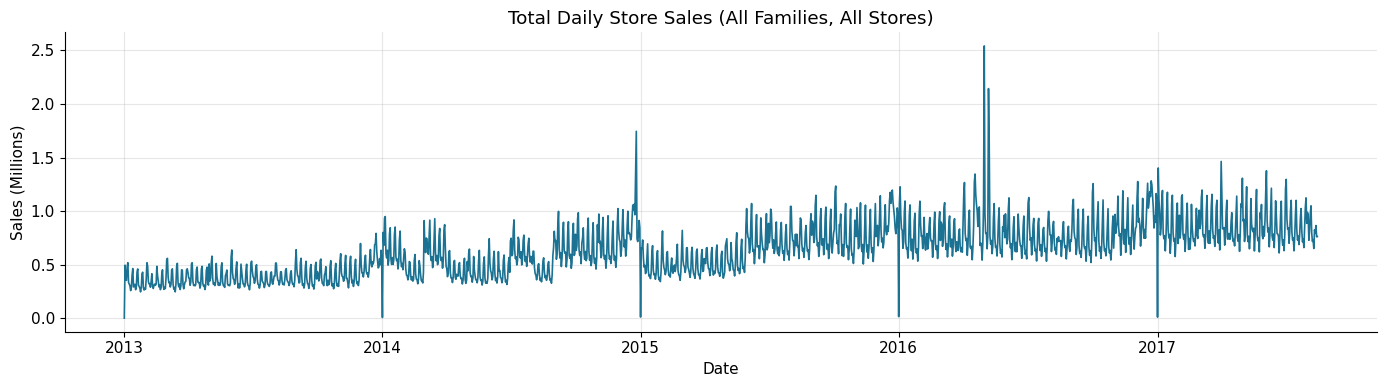

Plot saved: 01_aggregate_sales.png


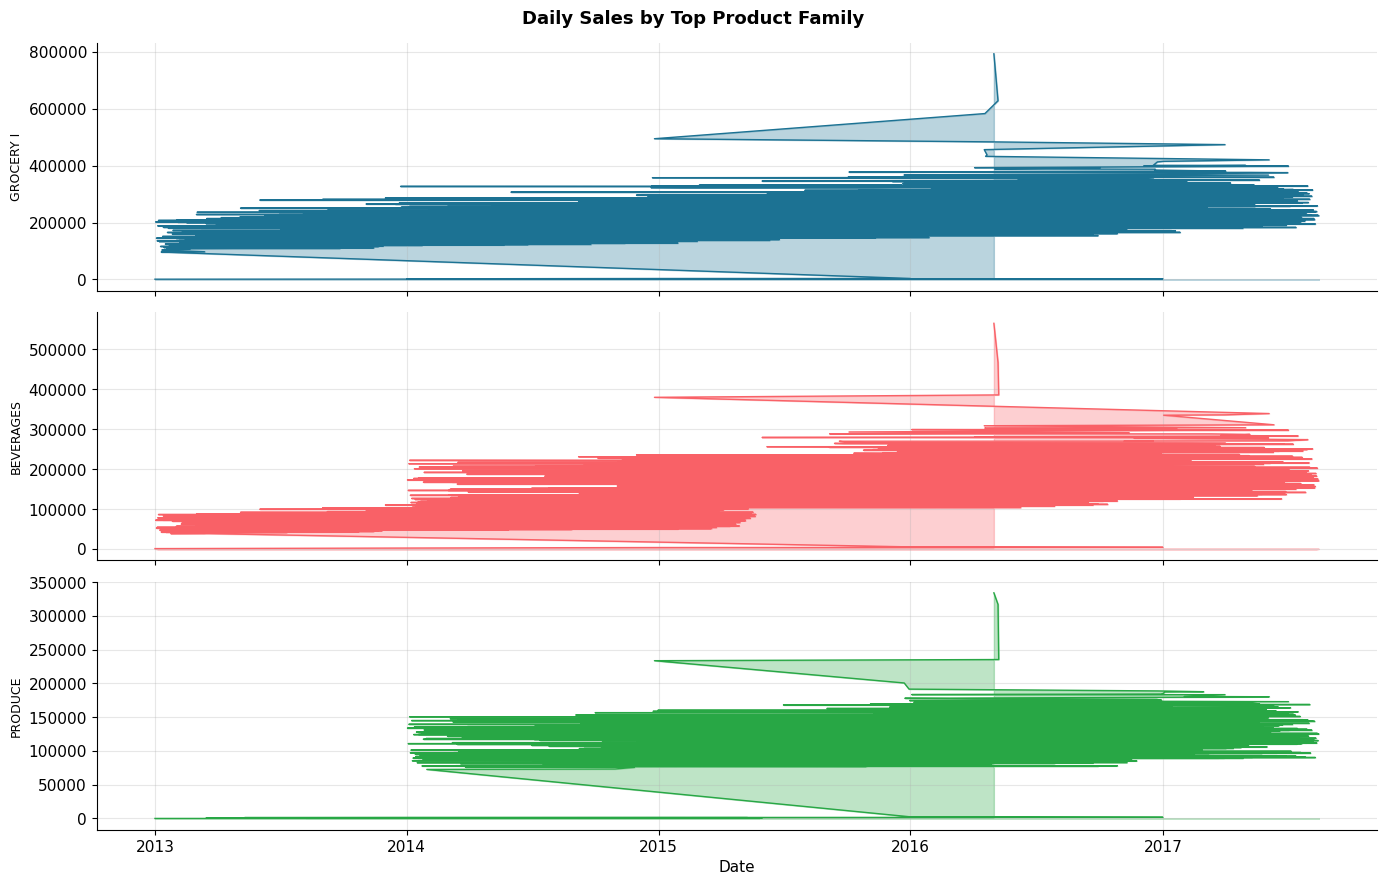

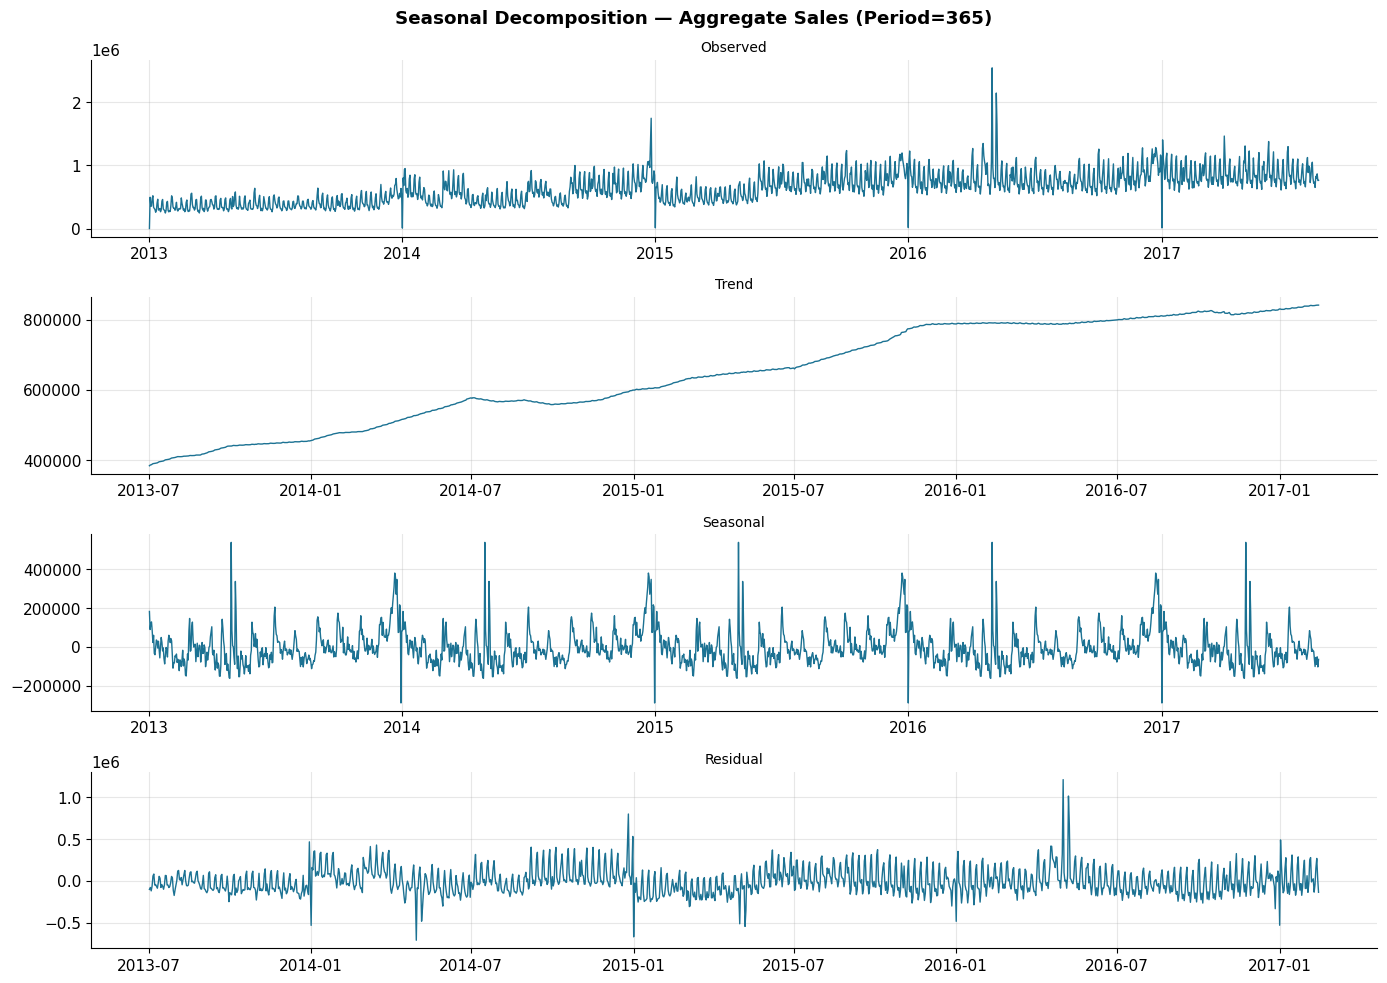

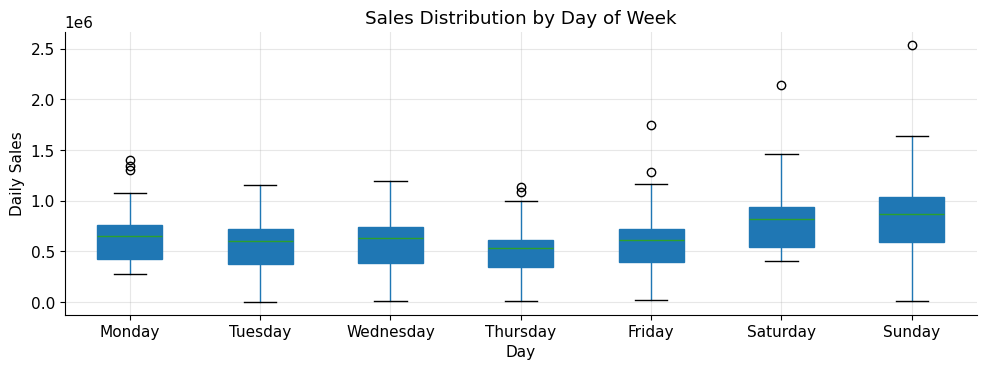

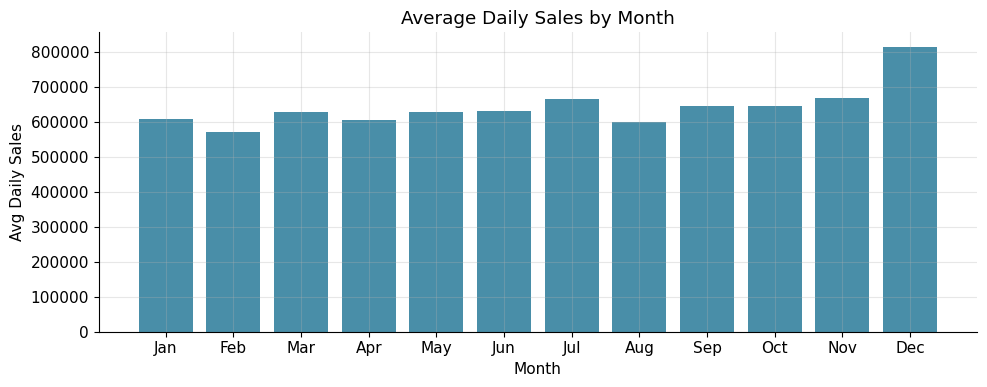

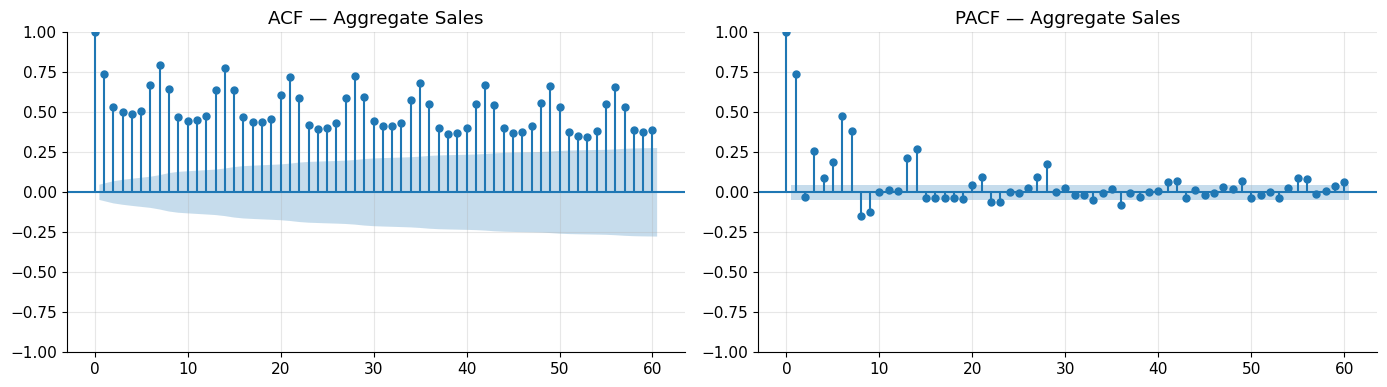


=== Stationarity Tests ===
  ADF  statistic: -2.6956  p-value: 0.0748
  -> ADF: Series may be non-stationary; differencing recommended
  KPSS statistic: 5.6703  p-value: 0.0100
  -> KPSS: Series may be non-stationary

EDA complete.

AGGREGATE SALES FORECAST
Training:   2013-01-01 → 2017-07-16 (1654 obs)
Validation: 2017-07-17   → 2017-08-15 (30 obs)

Fitting ARIMA (2, 1, 2)x(1, 1, 1, 7) for Aggregate...
  [ARIMA (Aggregate)]  MAE=1,035,627  RMSE=1,907,667  MAPE=58.85%
  AIC: 6727.2  |  BIC: 6740.9


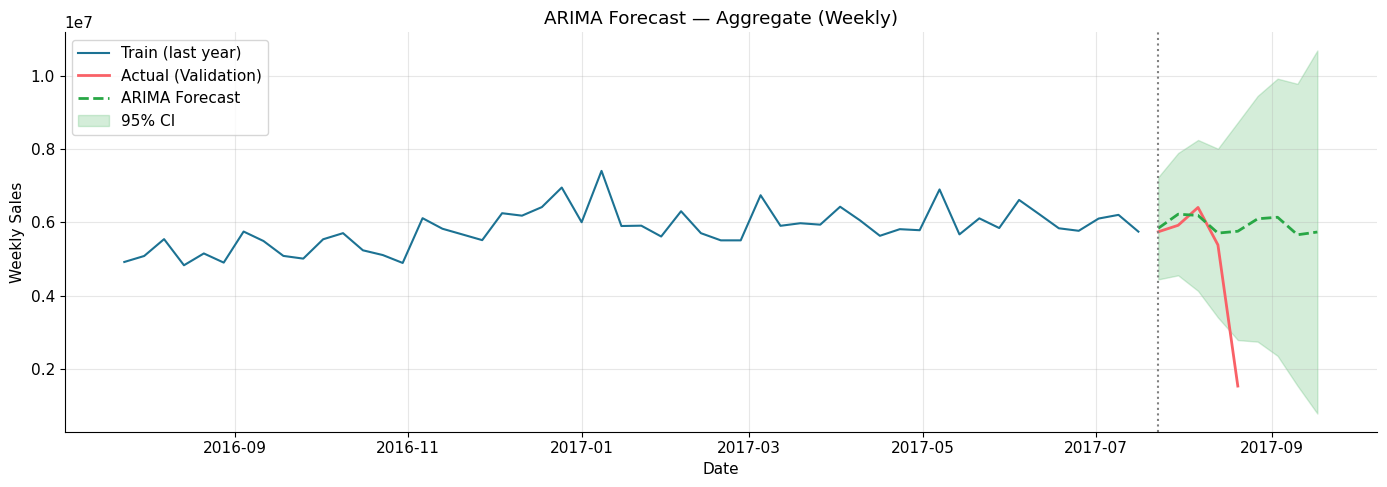

Plot saved: 07_arima_Aggregate.png

Fitting ETS (Holt-Winters) for Aggregate...
  [ETS (Aggregate)]  MAE=977,176  RMSE=1,754,620  MAPE=53.36%


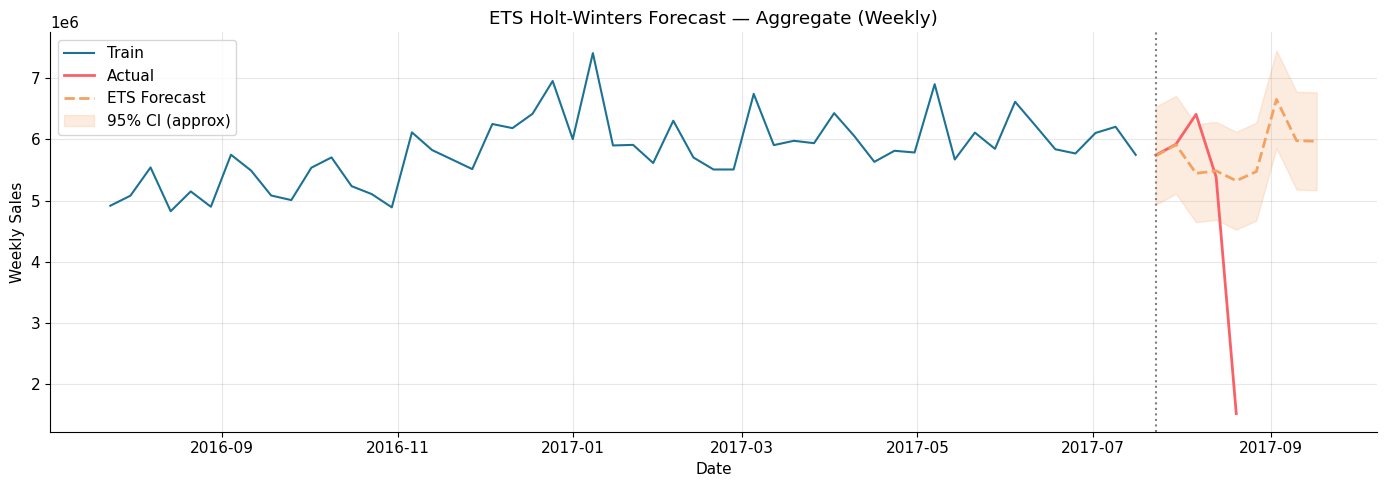


Fitting Prophet for Aggregate...


20:16:41 - cmdstanpy - INFO - Chain [1] start processing
20:16:42 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet (Aggregate)]  MAE=71,444  RMSE=96,111  MAPE=8.40%


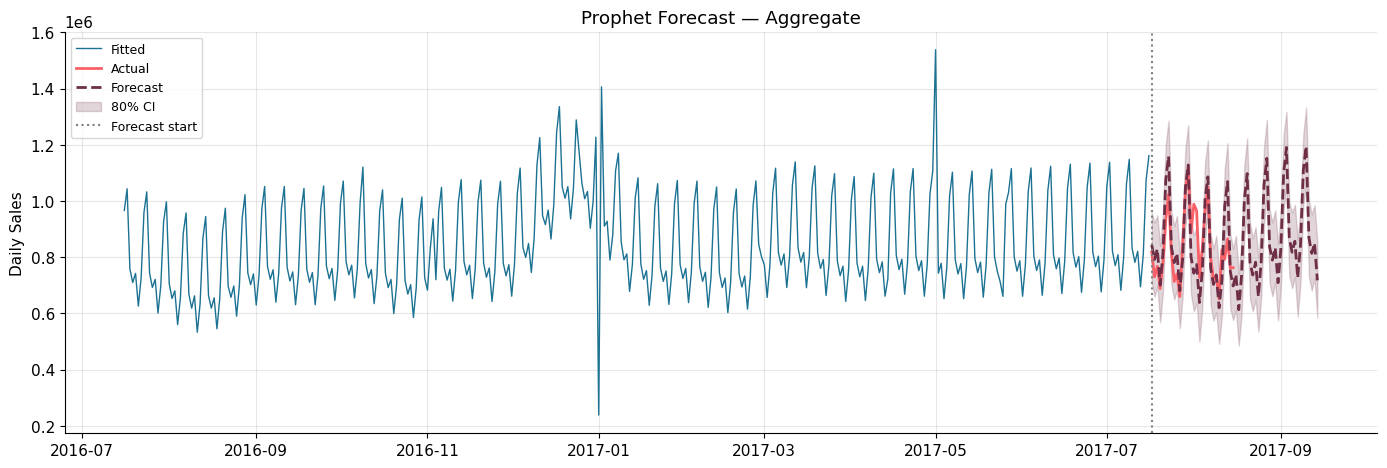

Plot saved: 09_prophet_Aggregate.png


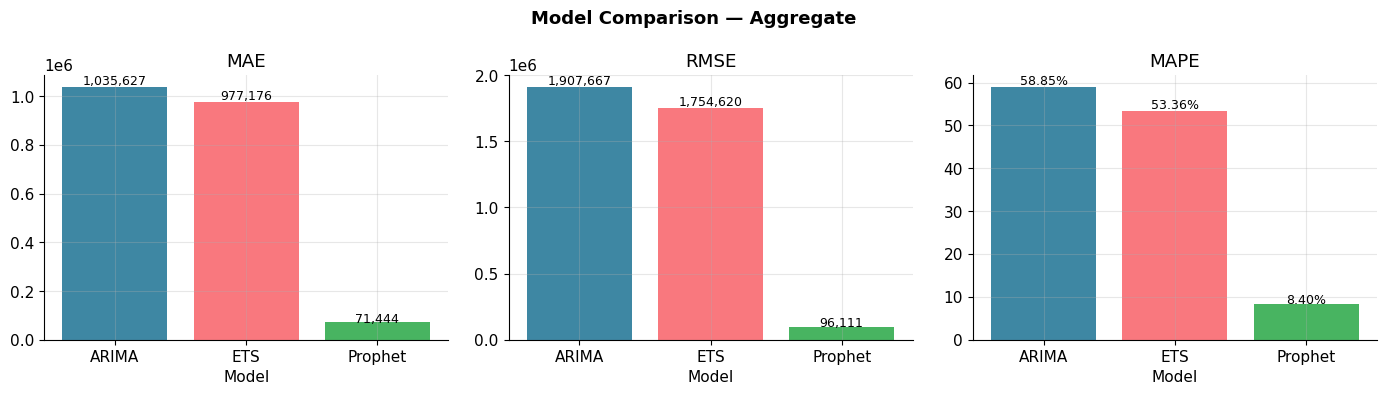


=== Model Comparison (Aggregate) ===
model_short          MAE         RMSE      MAPE
      ARIMA 1.035627e+06 1.907667e+06 58.848177
        ETS 9.771756e+05 1.754620e+06 53.357733
    Prophet 7.144450e+04 9.611076e+04  8.395391
  → Best model by MAPE: Prophet

Generating 30-day final forecast for Aggregate...


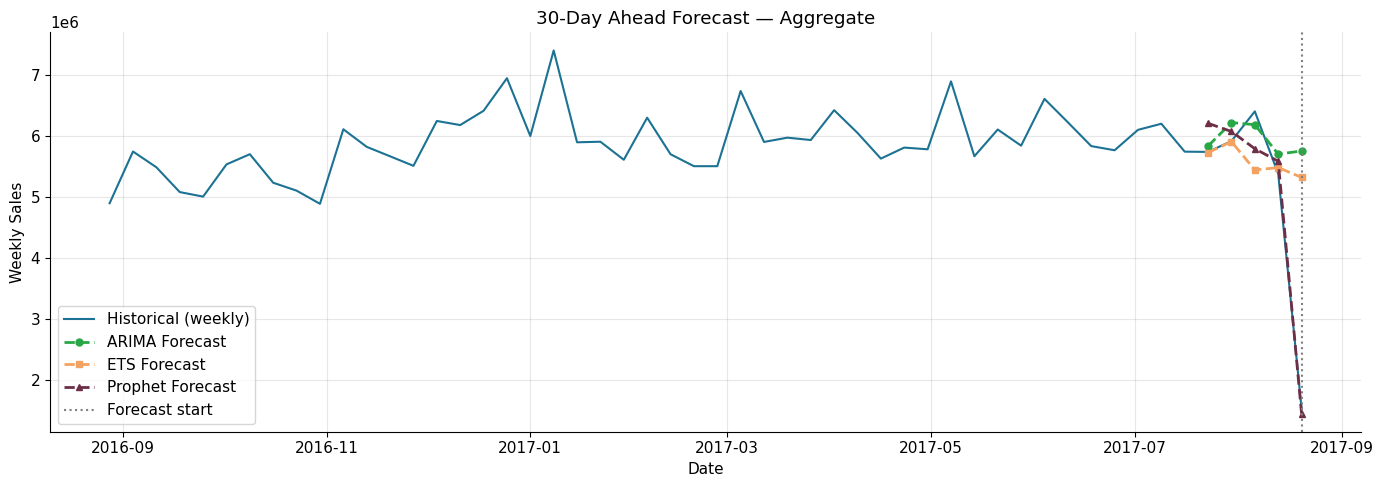

Plot saved: 11_final_forecast_Aggregate.png

PRODUCT FAMILY: GROCERY I
Training:   2013-01-01 → 2016-04-01 (1184 obs)
Validation: 2016-04-02   → 2017-08-15 (500 obs)

Fitting ARIMA (2, 1, 2)x(1, 1, 1, 7) for GROCERY I...
  [ARIMA (GROCERY I)]  MAE=4,605,601  RMSE=5,158,090  MAPE=281.91%
  AIC: 4333.2  |  BIC: 4345.5


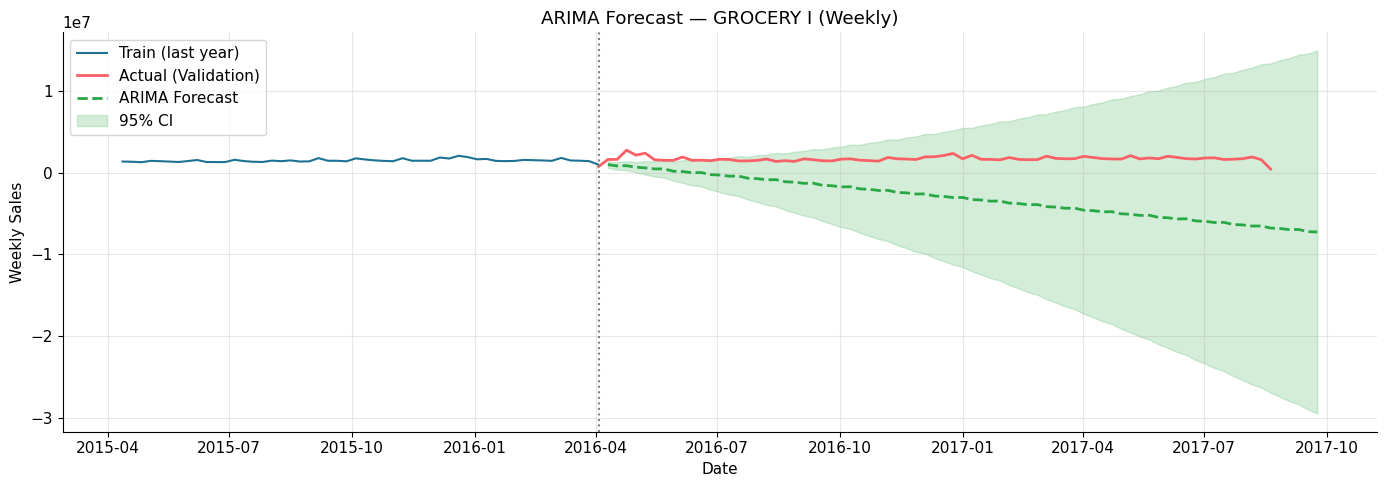

Plot saved: 07_arima_GROCERY_I.png

Fitting ETS (Holt-Winters) for GROCERY I...
  [ETS (GROCERY I)]  MAE=426,719  RMSE=500,420  MAPE=25.96%


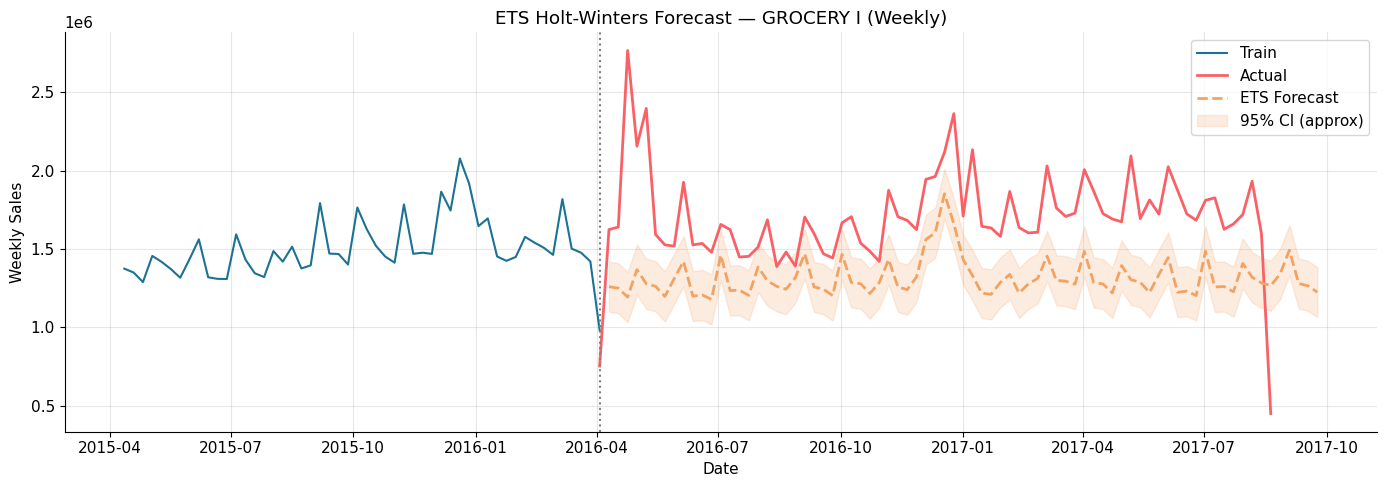


Fitting Prophet for GROCERY I...


20:16:49 - cmdstanpy - INFO - Chain [1] start processing
20:16:50 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet (GROCERY I)]  MAE=29,335  RMSE=49,254  MAPE=21.78%


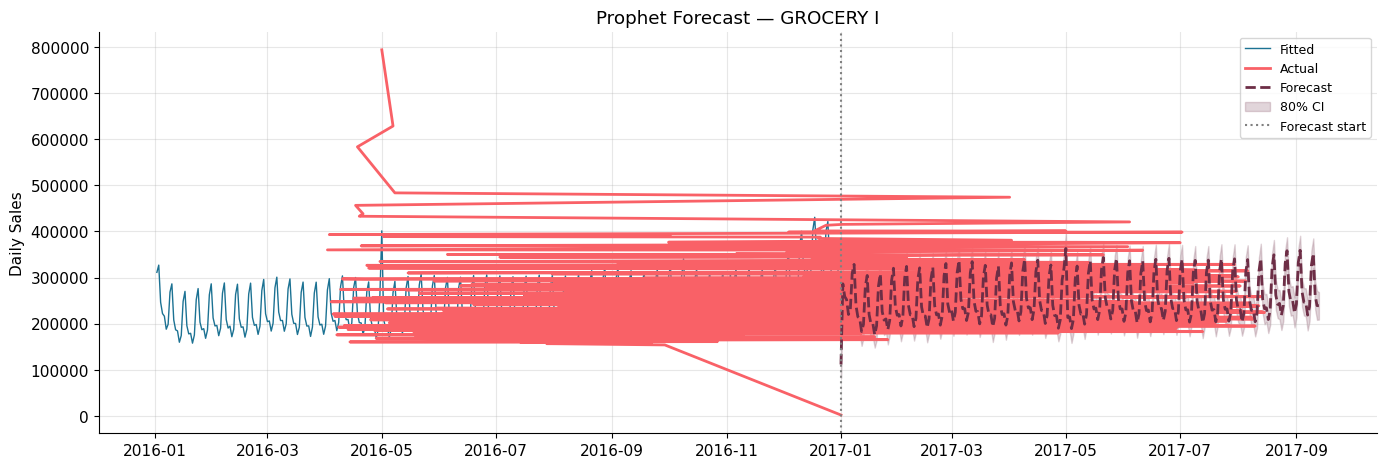

Plot saved: 09_prophet_GROCERY_I.png


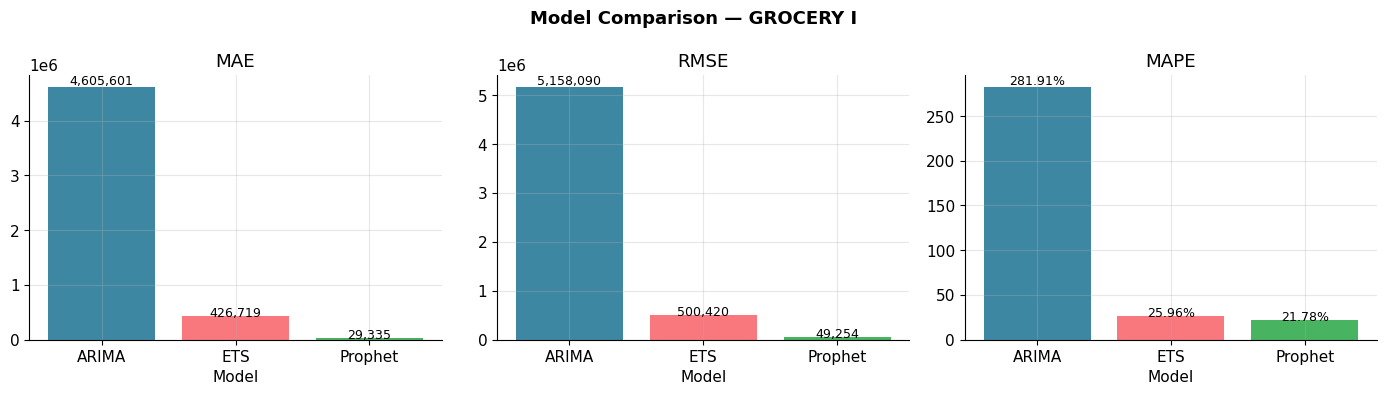


=== Model Comparison (GROCERY I) ===
model_short          MAE         RMSE       MAPE
      ARIMA 4.605601e+06 5.158090e+06 281.912169
        ETS 4.267190e+05 5.004202e+05  25.960794
    Prophet 2.933479e+04 4.925414e+04  21.778347
  → Best model by MAPE: Prophet

PRODUCT FAMILY: BEVERAGES
Training:   2013-01-01 → 2016-04-01 (1184 obs)
Validation: 2016-04-02   → 2017-08-15 (500 obs)

Fitting ARIMA (2, 1, 2)x(1, 1, 1, 7) for BEVERAGES...
  [ARIMA (BEVERAGES)]  MAE=1,076,468  RMSE=1,179,456  MAPE=85.49%
  AIC: 4317.3  |  BIC: 4329.6


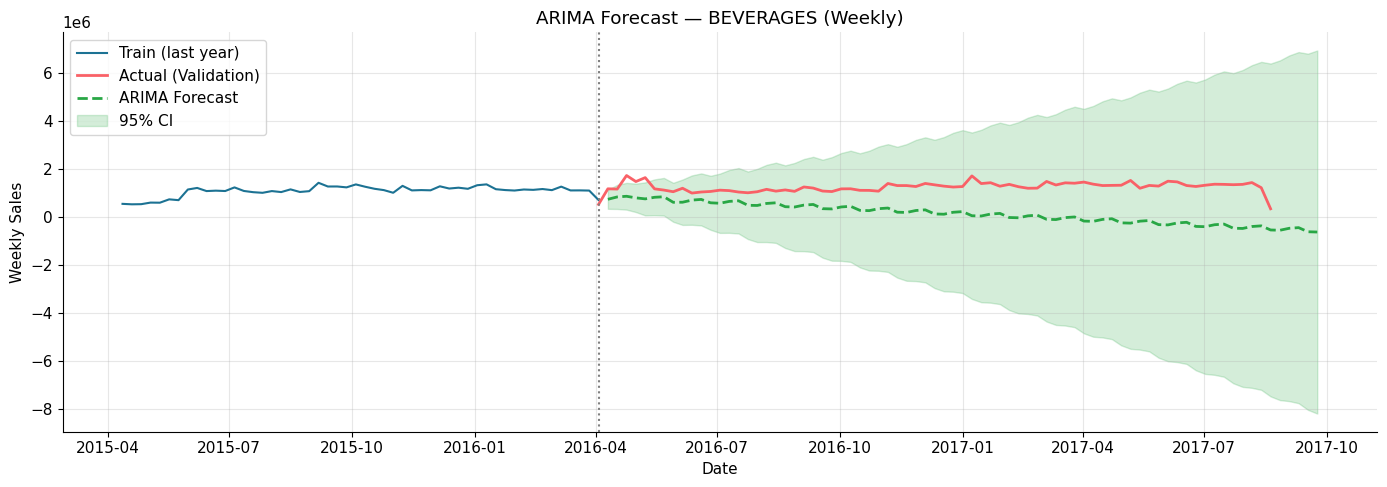

Plot saved: 07_arima_BEVERAGES.png

Fitting ETS (Holt-Winters) for BEVERAGES...
  [ETS (BEVERAGES)]  MAE=386,938  RMSE=451,187  MAPE=30.62%


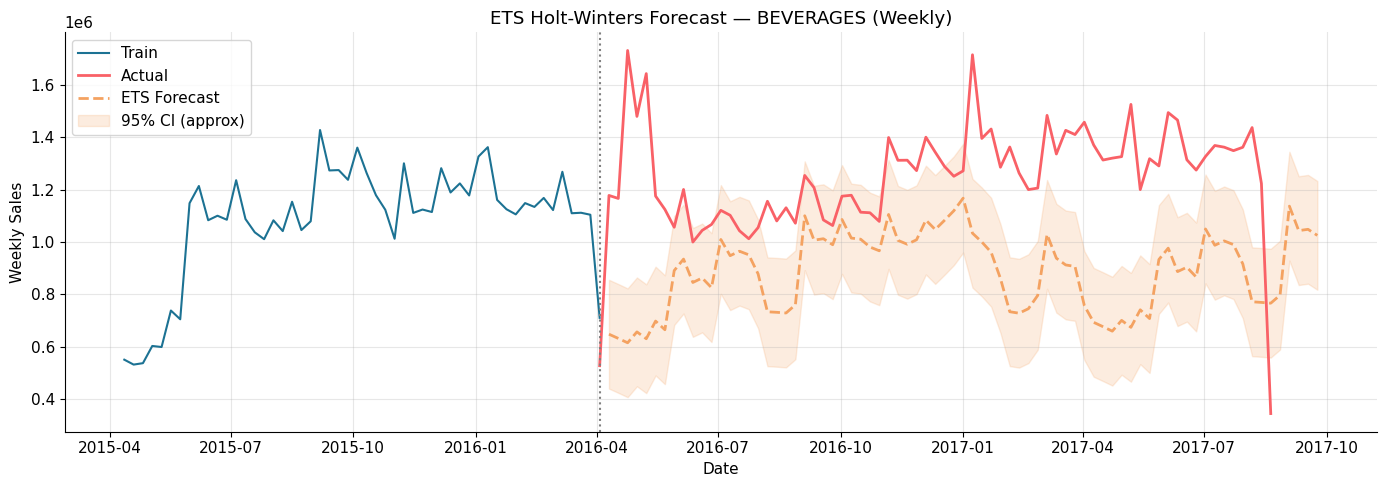


Fitting Prophet for BEVERAGES...


20:16:56 - cmdstanpy - INFO - Chain [1] start processing
20:16:57 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet (BEVERAGES)]  MAE=52,215  RMSE=64,652  MAPE=35.55%


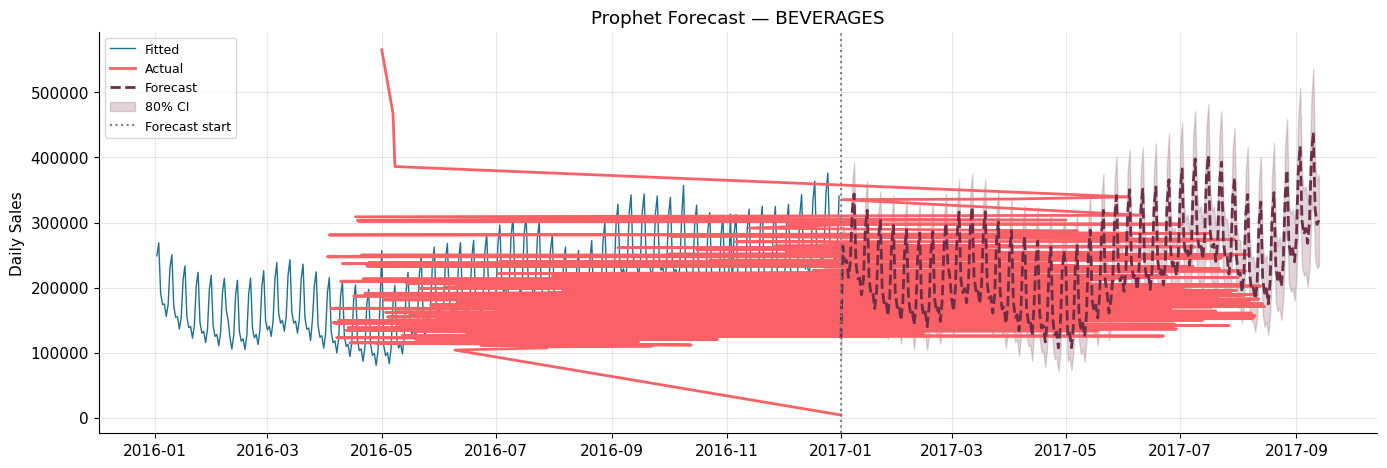

Plot saved: 09_prophet_BEVERAGES.png


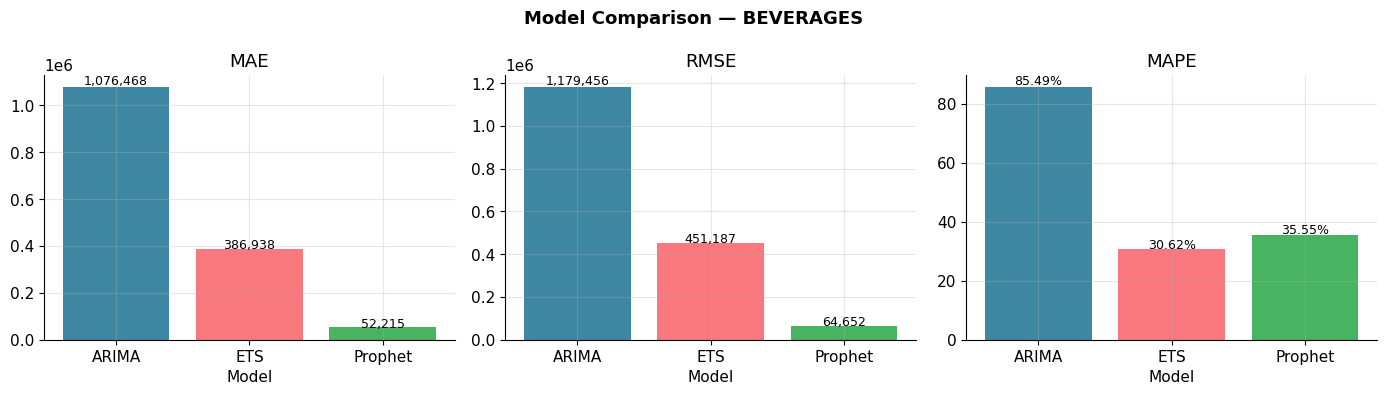


=== Model Comparison (BEVERAGES) ===
model_short          MAE         RMSE      MAPE
      ARIMA 1.076468e+06 1.179456e+06 85.489218
        ETS 3.869376e+05 4.511875e+05 30.621374
    Prophet 5.221451e+04 6.465216e+04 35.547638
  → Best model by MAPE: ETS

CONSOLIDATED RESULTS SUMMARY
    scope model_short          MAE         RMSE       MAPE
Aggregate       ARIMA 1.035627e+06 1.907667e+06  58.848177
Aggregate         ETS 9.771756e+05 1.754620e+06  53.357733
Aggregate     Prophet 7.144450e+04 9.611076e+04   8.395391
GROCERY I       ARIMA 4.605601e+06 5.158090e+06 281.912169
GROCERY I         ETS 4.267190e+05 5.004202e+05  25.960794
GROCERY I     Prophet 2.933479e+04 4.925414e+04  21.778347
BEVERAGES       ARIMA 1.076468e+06 1.179456e+06  85.489218
BEVERAGES         ETS 3.869376e+05 4.511875e+05  30.621374
BEVERAGES     Prophet 5.221451e+04 6.465216e+04  35.547638

Saved: results_summary.csv

All plots saved to ./plots/
Results saved to results_summary.csv
Pipeline complete!


In [ ]:
def summary_table(agg_results, family_results_dict):
    """Print and return consolidated results across all forecasts."""
    all_rows = []
    agg_results["scope"] = "Aggregate"
    all_rows.append(agg_results)

    for fam, df in family_results_dict.items():
        df["scope"] = fam
        all_rows.append(df)

    summary = pd.concat(all_rows, ignore_index=True)
    summary = summary[["scope","model_short","MAE","RMSE","MAPE"]]

    print("\n" + "="*70)
    print("CONSOLIDATED RESULTS SUMMARY")
    print("="*70)
    print(summary.to_string(index=False))
    summary.to_csv("results_summary.csv", index=False)
    print("\nSaved: results_summary.csv")
    return summary


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def main():
    print("=" * 60)
    print("ECON 5140 — Store Sales Time Series Forecasting")
    print("=" * 60)

    # Load data (use synthetic if Kaggle data not downloaded)
    if Path("./data/train.csv").exists():
        train, test, stores, oil, hol = load_data("./data")
    else:
        print("\nKaggle data not found at ./data/train.csv")
        print("Using synthetic demonstration data.\n")
        train, test, stores, oil, hol = generate_synthetic_data()

    # Preprocessing
    df = preprocess(train, stores, oil, hol)

    # Build time series
    agg = build_aggregate_series(df)
    family_dict, top_families = build_family_series(df, top_n=3)

    # EDA
    print("\n--- Exploratory Data Analysis ---")
    eda_aggregate(agg, family_dict, top_families)

    # =========================================================
    # A. AGGREGATE FORECAST
    # =========================================================
    print("\n" + "="*60)
    print("AGGREGATE SALES FORECAST")
    print("="*60)

    train_agg, val_agg = train_val_split(agg["sales"], val_days=30)
    agg_metrics = []

    # ARIMA
    arima_res, arima_pred, arima_ci, m1, tw, vw = fit_arima(train_agg, val_agg, label="Aggregate")
    plot_arima(tw, vw, arima_pred, arima_ci, label="Aggregate")
    agg_metrics.append(m1)

    # ETS
    ets_res, ets_fc, ets_lo, ets_hi, m2, tw2, vw2 = fit_ets(train_agg, val_agg, label="Aggregate")
    plot_ets(tw2, vw2, ets_fc, ets_lo, ets_hi, label="Aggregate")
    agg_metrics.append(m2)

    # Prophet
    prophet_m, prophet_fc, val_fc, m3 = fit_prophet(train_agg, val_agg, label="Aggregate")
    plot_prophet(prophet_m, prophet_fc, val_agg, label="Aggregate")
    if m3: agg_metrics.append(m3)

    agg_results = compare_models(agg_metrics, label="Aggregate")
    final_forecast_plot(agg["sales"], arima_res, ets_res, prophet_m, prophet_fc, label="Aggregate")

    # =========================================================
    # B. PRODUCT FAMILY FORECASTS (Top 2 families)
    # =========================================================
    family_results = {}
    for fam in top_families[:2]:
        res = run_family_forecast(family_dict[fam], fam)
        family_results[fam] = res

    # =========================================================
    # C. SUMMARY
    # =========================================================
    summary = summary_table(agg_results, family_results)

    print("\n" + "="*60)
    print("All plots saved to ./plots/")
    print("Results saved to results_summary.csv")
    print("Pipeline complete!")
    print("="*60)

    return summary


# Run pipeline and capture results (all prints and plots appear below)
summary = main()